# 03. Analisis de Sentimiento

Analisis de sentimiento multilingual con `nlptown/bert-base-multilingual-uncased-sentiment` (BERT fine-tuned para clasificar textos en 1-5 estrellas).

**Datos analizados:**
- Comentarios Instagram (US + Europa)
- Comentarios TikTok (US + Europa)
- Reviews Trustpilot (Lululemon + ALO Yoga)

**Clasificacion:**
- 1-2 estrellas → Negativo
- 3 estrellas → Neutro
- 4-5 estrellas → Positivo

In [1]:
import sys
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentiment import predict_sentiment
from plotting import setup_style, save_fig, COLORS, PLATFORM_COLORS
setup_style()

DATA = "../../datos/clean"

In [2]:
ig_com = pd.read_csv(f"{DATA}/ig_comentarios.csv")
tk_com = pd.read_csv(f"{DATA}/tiktok_comentarios.csv")
tp = pd.read_csv(f"{DATA}/trustpilot_all.csv")

print(f"IG comentarios: {len(ig_com)}")
print(f"TK comentarios: {len(tk_com)}")
print(f"Trustpilot reviews: {len(tp)}")

IG comentarios: 1433
TK comentarios: 1056
Trustpilot reviews: 383


## 1. Sentimiento - Comentarios Instagram

In [3]:
print("Analizando sentimiento Instagram...")
ig_sent = predict_sentiment(ig_com["text_clean"].tolist())
ig_com = pd.concat([ig_com, ig_sent], axis=1)
print(f"Completado. Distribucion:")
print(ig_com["sentiment_label"].value_counts())

Analizando sentimiento Instagram...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Completado. Distribucion:
sentiment_label
positivo    737
negativo    504
neutro      192
Name: count, dtype: int64


## 2. Sentimiento - Comentarios TikTok

In [4]:
print("Analizando sentimiento TikTok...")
tk_sent = predict_sentiment(tk_com["text_clean"].tolist())
tk_com = pd.concat([tk_com, tk_sent], axis=1)
print(f"Completado. Distribucion:")
print(tk_com["sentiment_label"].value_counts())

Analizando sentimiento TikTok...
Completado. Distribucion:
sentiment_label
positivo    491
negativo    371
neutro      194
Name: count, dtype: int64


## 3. Sentimiento - Reviews Trustpilot

Trustpilot ya tiene rating explicito (1-5), pero analizamos el sentimiento del texto para comparar.

In [5]:
print("Analizando sentimiento Trustpilot...")
tp_sent = predict_sentiment(tp["text_clean"].tolist())
tp = pd.concat([tp, tp_sent], axis=1)

# Comparar rating real vs sentimiento predicho
tp["rating_label"] = pd.cut(tp["rating"], bins=[0, 2, 3, 5], labels=["negativo", "neutro", "positivo"])
concordancia = (tp["rating_label"] == tp["sentiment_label"]).mean()
print(f"\nConcordancia rating vs sentimiento BERT: {concordancia:.1%}")
print(f"\nDistribucion sentimiento BERT:")
print(tp["sentiment_label"].value_counts())

Analizando sentimiento Trustpilot...

Concordancia rating vs sentimiento BERT: 95.6%

Distribucion sentimiento BERT:
sentiment_label
negativo    349
positivo     29
neutro        5
Name: count, dtype: int64


## 4. Visualizacion del sentimiento por plataforma

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_por_plataforma.png


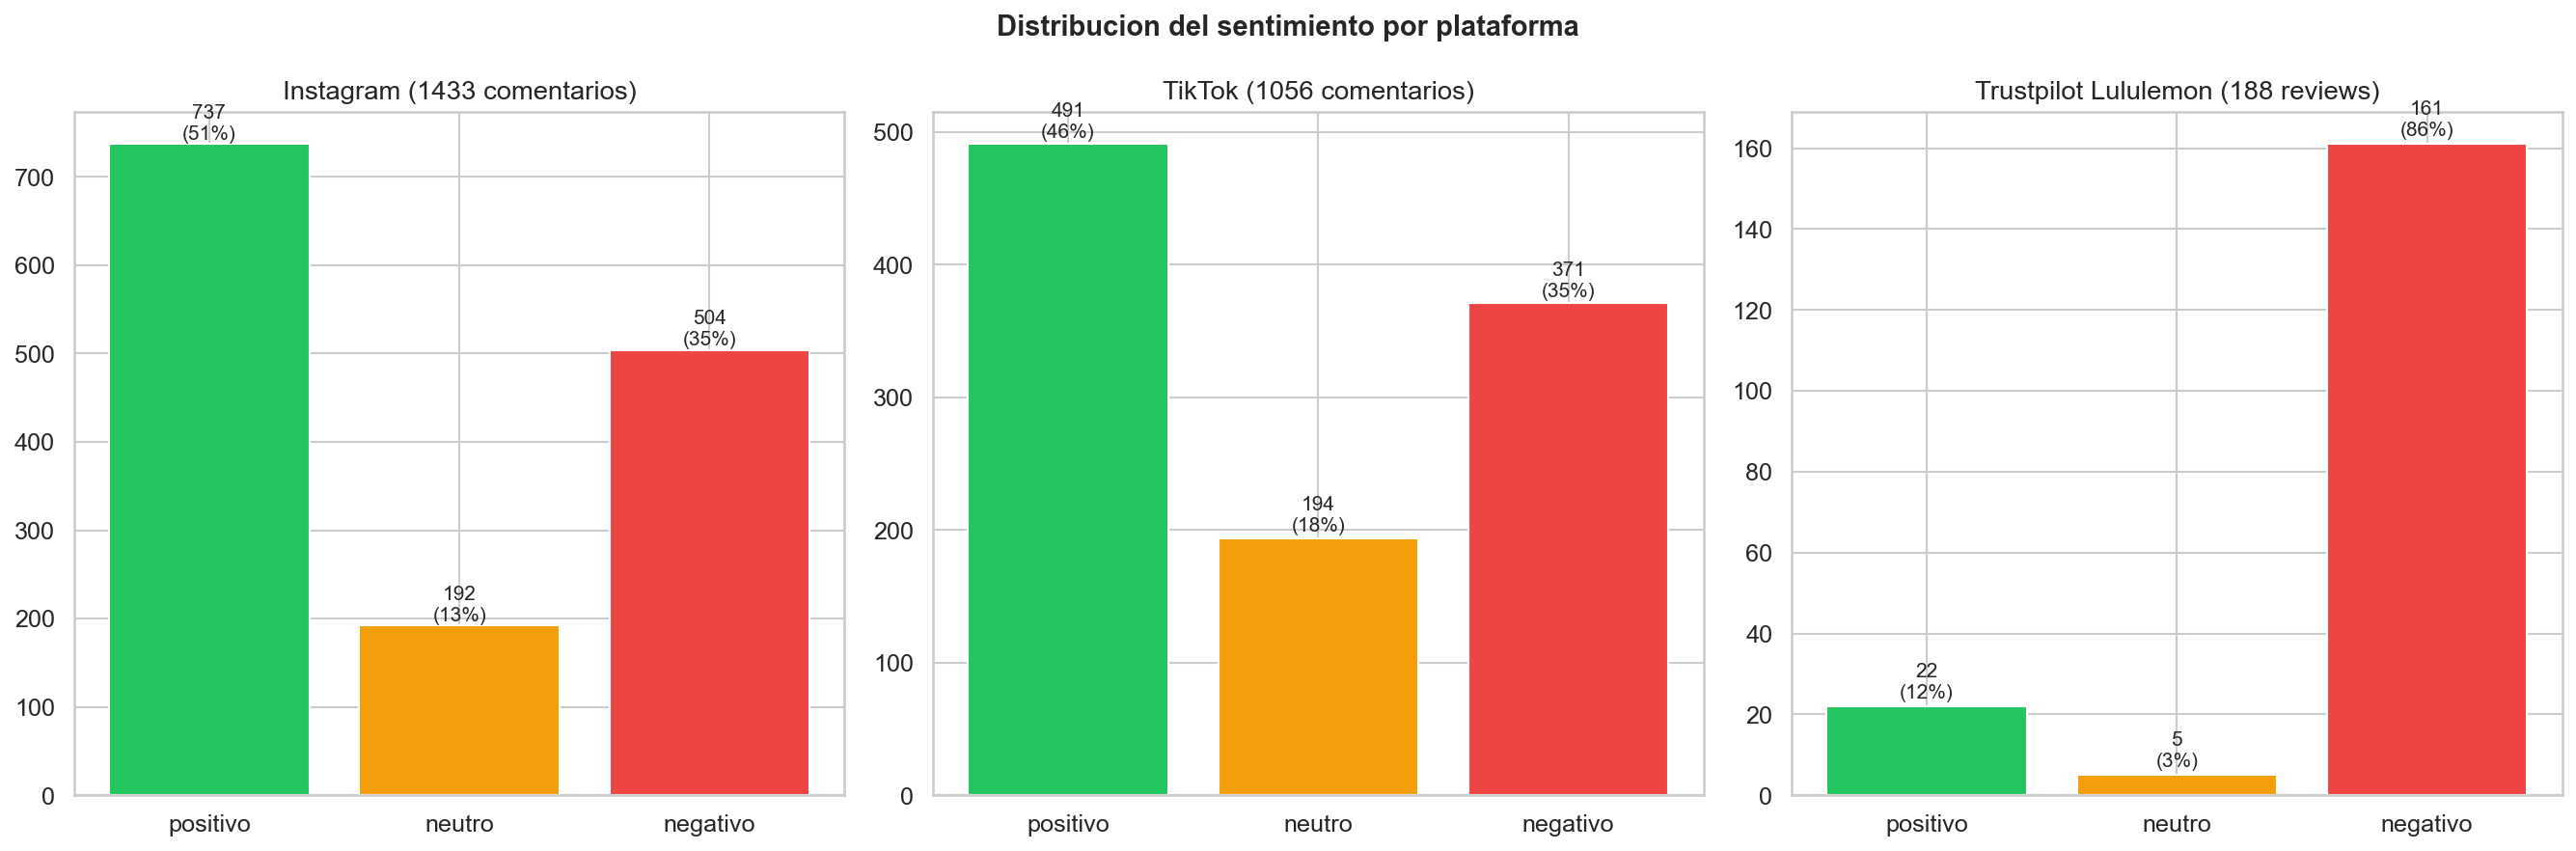

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sent_order = ["positivo", "neutro", "negativo"]
colors_sent = [COLORS["positive"], COLORS["neutral"], COLORS["negative"]]

# Instagram
ig_counts = ig_com["sentiment_label"].value_counts().reindex(sent_order)
axes[0].bar(sent_order, ig_counts.values, color=colors_sent)
axes[0].set_title(f"Instagram ({len(ig_com)} comentarios)")
for i, v in enumerate(ig_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v/len(ig_com)*100:.0f}%)", ha="center", fontsize=10)

# TikTok
tk_counts = tk_com["sentiment_label"].value_counts().reindex(sent_order)
axes[1].bar(sent_order, tk_counts.values, color=colors_sent)
axes[1].set_title(f"TikTok ({len(tk_com)} comentarios)")
for i, v in enumerate(tk_counts.values):
    axes[1].text(i, v + 5, f"{v}\n({v/len(tk_com)*100:.0f}%)", ha="center", fontsize=10)

# Trustpilot
tp_lulu = tp[tp["brand"] == "Lululemon"]
tp_counts = tp_lulu["sentiment_label"].value_counts().reindex(sent_order)
axes[2].bar(sent_order, tp_counts.values, color=colors_sent)
axes[2].set_title(f"Trustpilot Lululemon ({len(tp_lulu)} reviews)")
for i, v in enumerate(tp_counts.values):
    axes[2].text(i, v + 2, f"{v}\n({v/len(tp_lulu)*100:.0f}%)", ha="center", fontsize=10)

plt.suptitle("Distribucion del sentimiento por plataforma", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "sent_por_plataforma")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_estrellas_detalle.png


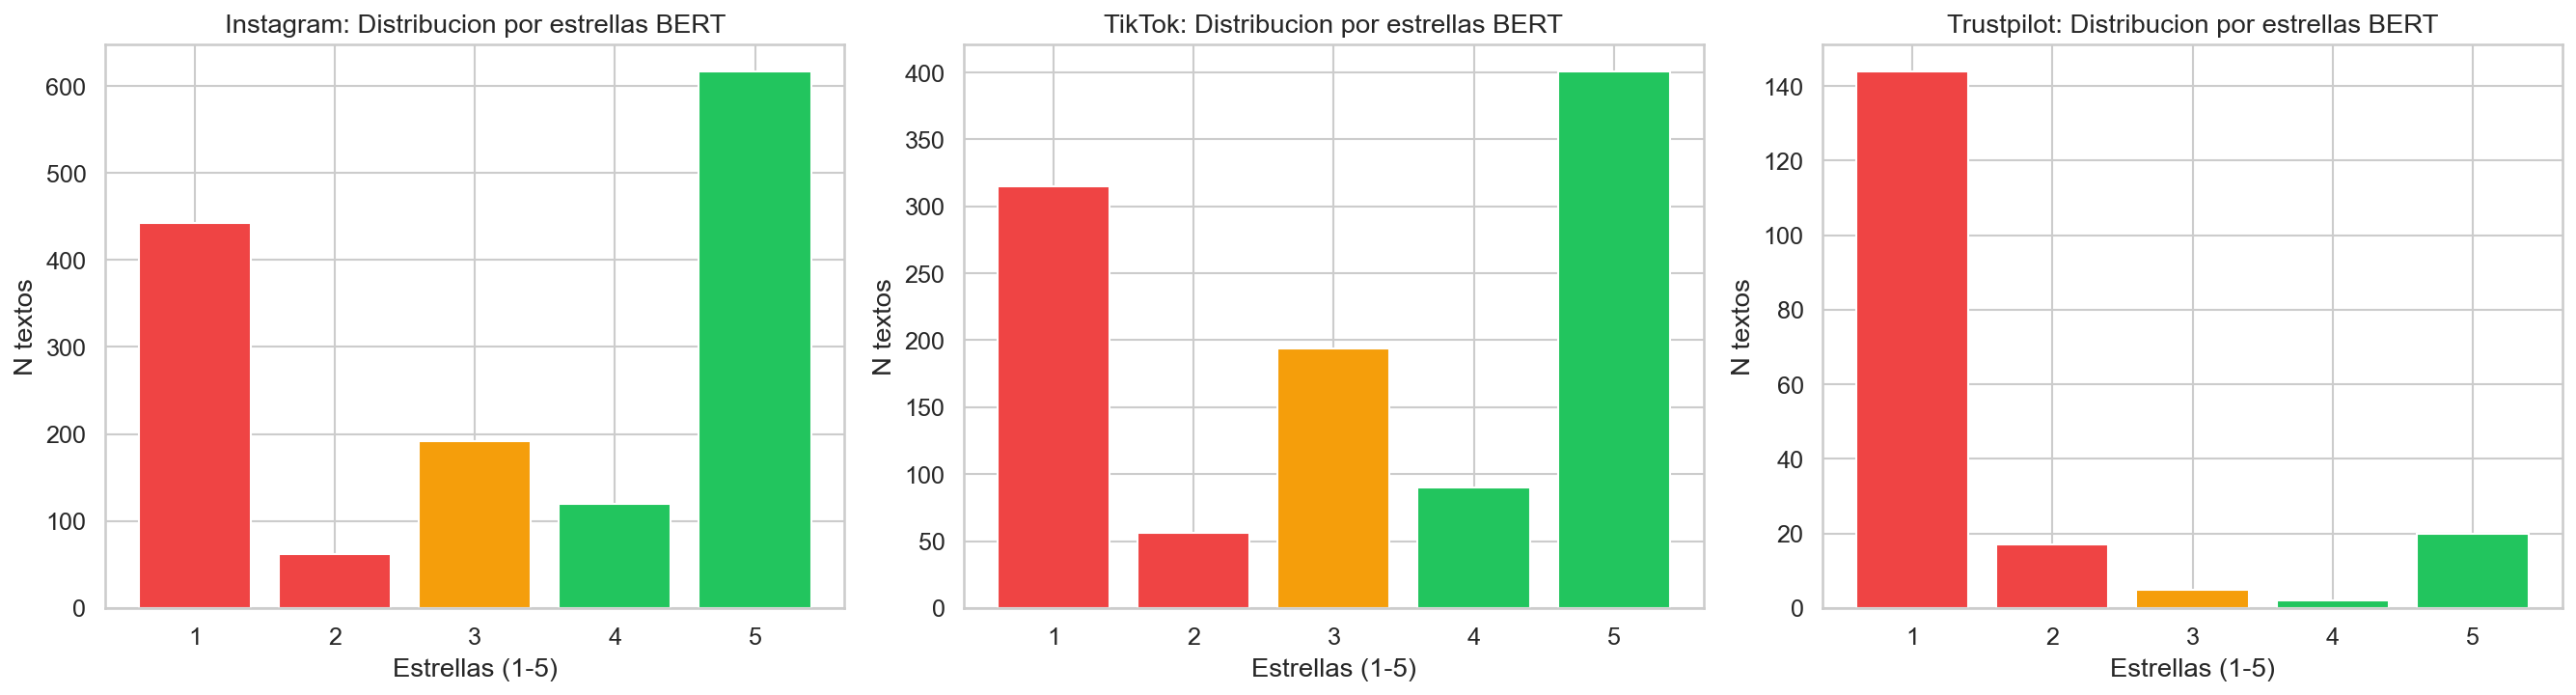

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df) in zip(axes, [("Instagram", ig_com), ("TikTok", tk_com), ("Trustpilot", tp_lulu)]):
    stars_dist = df["sentiment_stars"].value_counts().sort_index()
    ax.bar(stars_dist.index, stars_dist.values, color=[COLORS["negative"], COLORS["negative"],
           COLORS["neutral"], COLORS["positive"], COLORS["positive"]])
    ax.set_title(f"{label}: Distribucion por estrellas BERT")
    ax.set_xlabel("Estrellas (1-5)")
    ax.set_ylabel("N textos")
    ax.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
save_fig(fig, "sent_estrellas_detalle")
plt.show()

## 5. Que dicen los comentarios negativos?

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_wordcloud_negativos.png


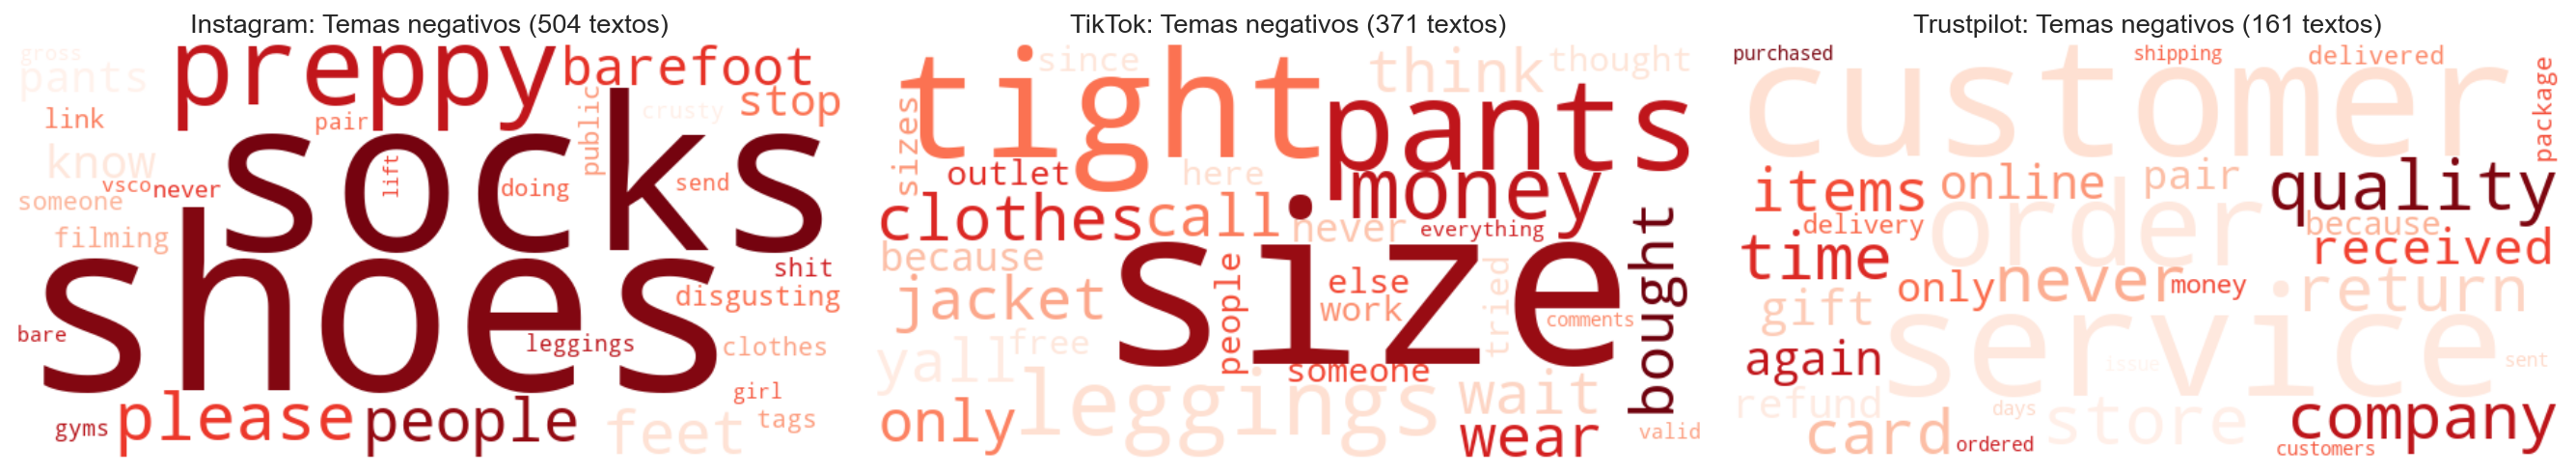

In [8]:
from wordcloud import WordCloud
from collections import Counter
import re

def get_top_words(texts, n=30, min_len=4):
    stopwords = {"this", "that", "with", "have", "from", "they", "them", "their", "your", "would",
                 "been", "were", "will", "just", "more", "como", "para", "pero", "este", "esta",
                 "very", "much", "also", "about", "what", "when", "than", "some", "lululemon", "the",
                 "like", "there", "where", "thing", "things", "said", "could", "even", "really",
                 "literally", "right", "first", "then", "those", "these", "need", "find", "look",
                 "lulu", "uber", "didn", "same", "which", "should", "after", "back", "told"}
    words = []
    for text in texts:
        if pd.isna(text):
            continue
        tokens = re.findall(r'\b[a-zA-Z\u00e1\u00e9\u00ed\u00f3\u00fa\u00f1\u00fc]+\b', str(text).lower())
        words.extend([w for w in tokens if len(w) >= min_len and w not in stopwords])
    return Counter(words).most_common(n)

# Comentarios negativos por plataforma
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df) in zip(axes, [("Instagram", ig_com), ("TikTok", tk_com), ("Trustpilot", tp_lulu)]):
    neg_texts = df[df["sentiment_label"] == "negativo"]["text_clean"]
    if len(neg_texts) > 5:
        wc_data = dict(get_top_words(neg_texts))
        wc = WordCloud(width=600, height=300, background_color="white",
                       colormap="Reds").generate_from_frequencies(wc_data)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label}: Temas negativos ({len(neg_texts)} textos)")

plt.tight_layout()
save_fig(fig, "sent_wordcloud_negativos")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_wordcloud_positivos.png


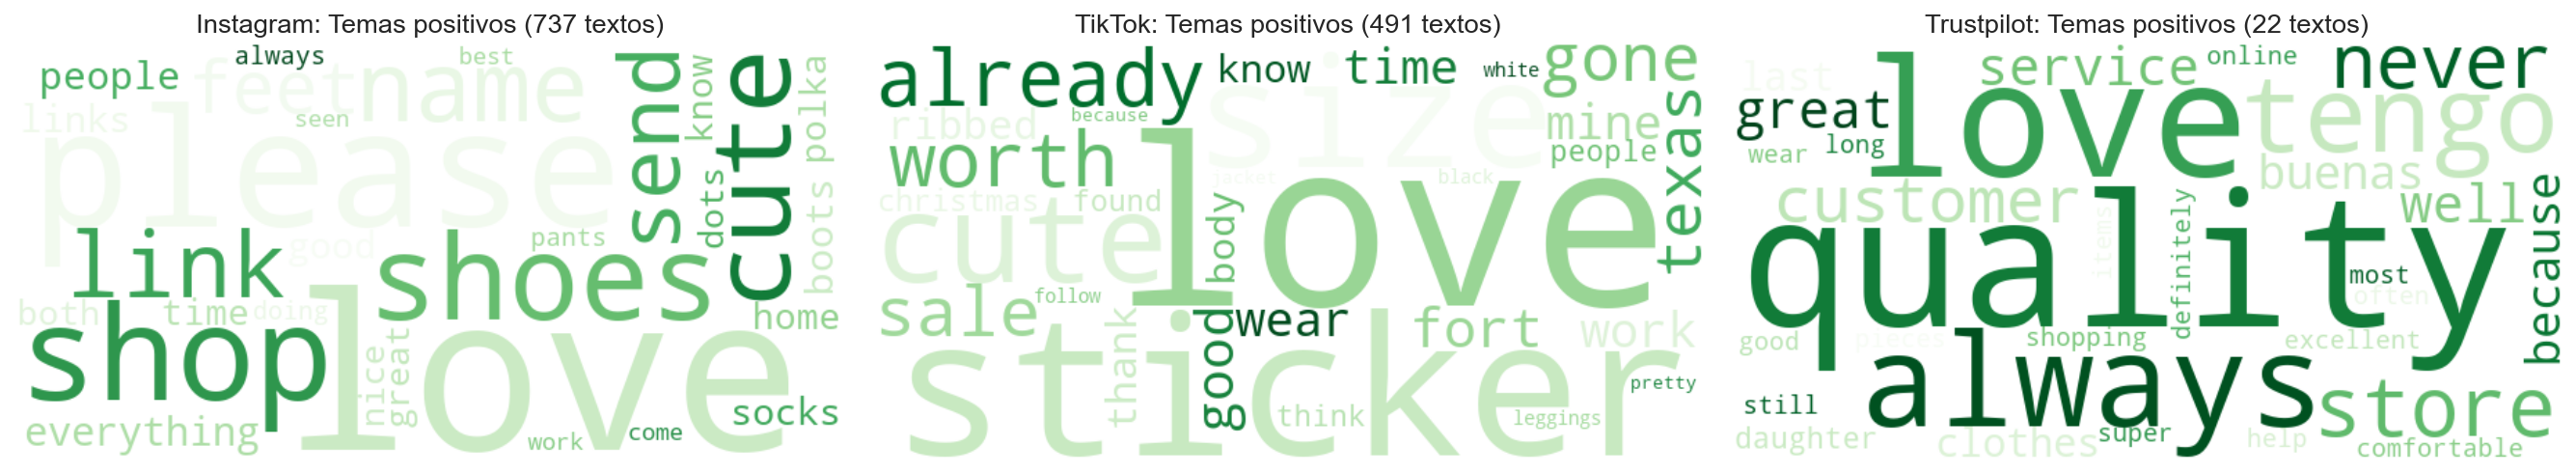

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df) in zip(axes, [("Instagram", ig_com), ("TikTok", tk_com), ("Trustpilot", tp_lulu)]):
    pos_texts = df[df["sentiment_label"] == "positivo"]["text_clean"]
    if len(pos_texts) > 5:
        wc_data = dict(get_top_words(pos_texts))
        wc = WordCloud(width=600, height=300, background_color="white",
                       colormap="Greens").generate_from_frequencies(wc_data)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label}: Temas positivos ({len(pos_texts)} textos)")

plt.tight_layout()
save_fig(fig, "sent_wordcloud_positivos")
plt.show()

## 5.1 Sentimiento general por region

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_general_por_region.png


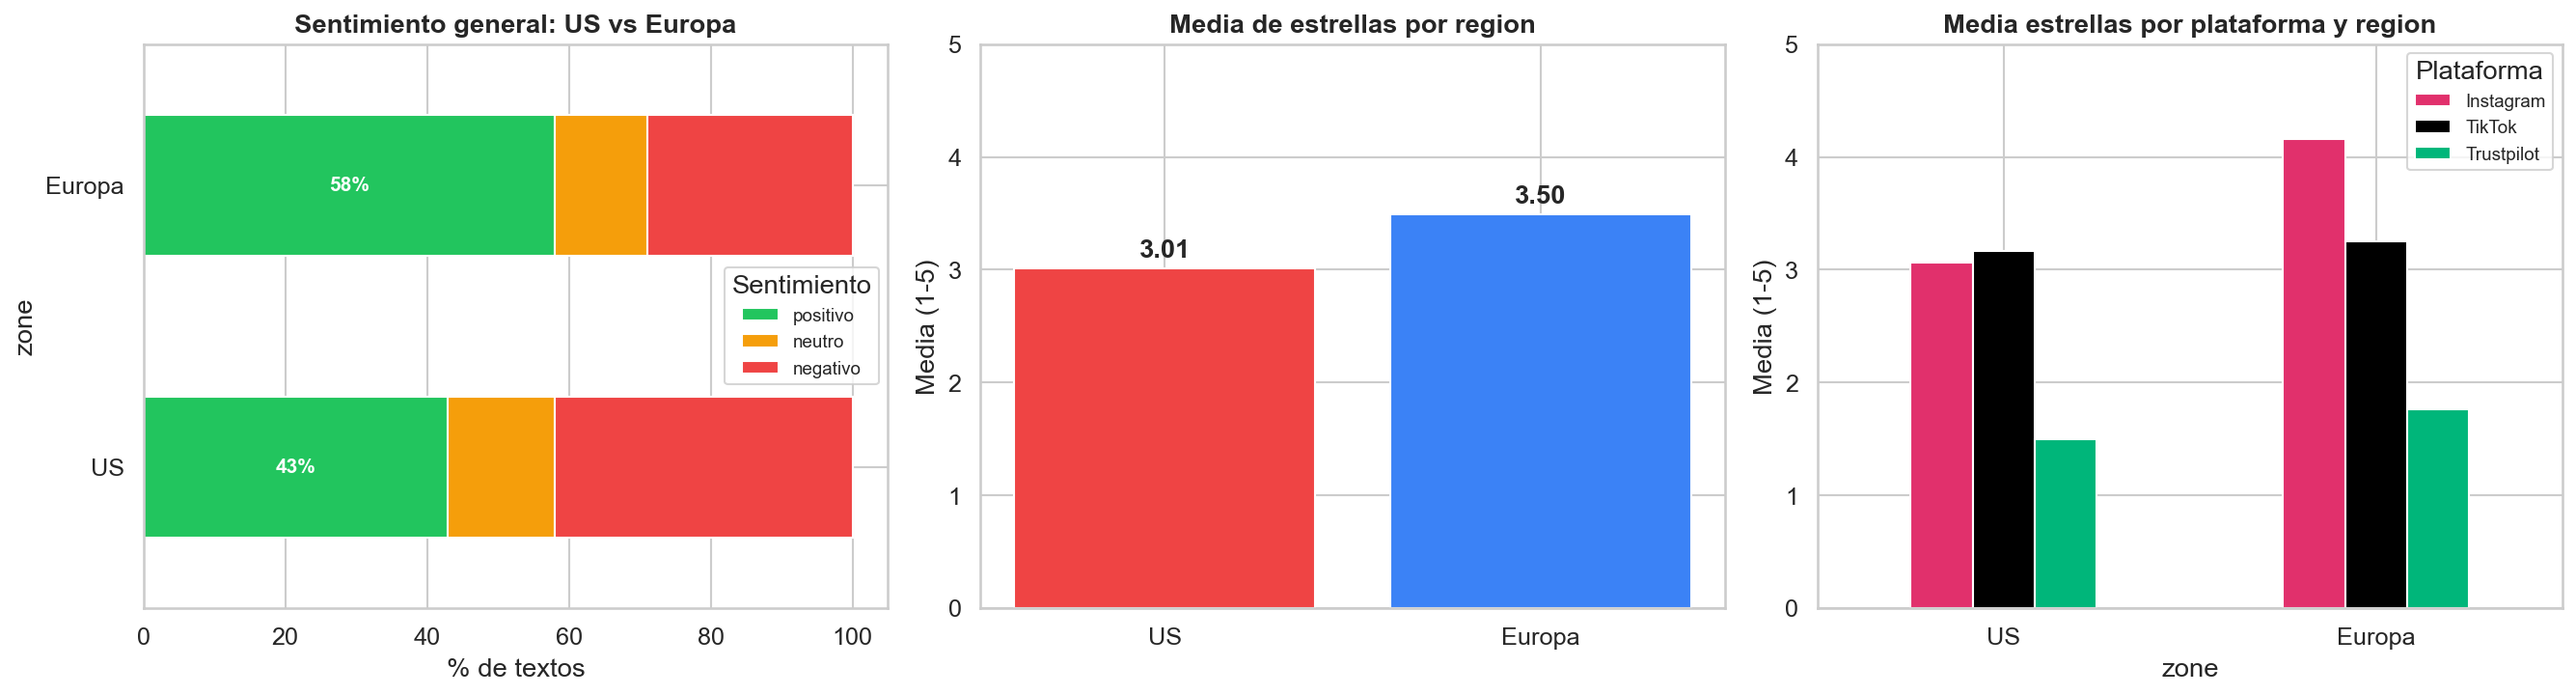

SENTIMIENTO GENERAL POR REGION
------------------------------------------------------------
  US: n=1953, positivo=42.9%, neutro=15.2%, negativo=41.9%, media=3.01
  Europa: n=709, positivo=58.0%, neutro=13.1%, negativo=28.9%, media=3.50

POR PLATAFORMA Y REGION
------------------------------------------------------------
  US / Instagram: n=1146, +45.1% / -40.8%, media=3.07
  US / TikTok: n=693, +44.7% / -36.2%, media=3.16
  US / Trustpilot: n=114, +8.8% / -87.7%, media=1.50
  Europa / Instagram: n=287, +76.7% / -12.5%, media=4.16
  Europa / TikTok: n=363, +49.9% / -33.1%, media=3.25
  Europa / Trustpilot: n=59, +16.9% / -83.1%, media=1.76


In [10]:
# Sentimiento general por region
ig_com_z = ig_com.copy()
ig_com_z["zone"] = ig_com_z["region"].apply(lambda x: "US" if x == "US" else "Europa")
ig_com_z["platform"] = "Instagram"

tk_com_z = tk_com.copy()
tk_com_z["zone"] = tk_com_z["region_search"].apply(lambda x: "US" if x == "US" else "Europa")
tk_com_z["platform"] = "TikTok"

EU_COUNTRIES = ["GB", "ES", "DE", "FR", "NL", "IE", "IT", "FI", "RO", "AT", "BE", "PT", "SE", "DK", "NO", "CH"]
US_COUNTRIES = ["US", "CA"]
tp_lulu_z = tp[tp["brand"] == "Lululemon"].copy()
tp_lulu_z["zone"] = tp_lulu_z["country"].apply(lambda x: "US" if x in US_COUNTRIES else ("Europa" if x in EU_COUNTRIES else "Otro"))
tp_lulu_z["platform"] = "Trustpilot"

all_with_zone = pd.concat([
    ig_com_z[["sentiment_label", "sentiment_stars", "zone", "platform"]],
    tk_com_z[["sentiment_label", "sentiment_stars", "zone", "platform"]],
    tp_lulu_z[["sentiment_label", "sentiment_stars", "zone", "platform"]],
], ignore_index=True)
all_with_zone = all_with_zone[all_with_zone["zone"].isin(["US", "Europa"])]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sent_order = ["positivo", "neutro", "negativo"]
colors_sent = [COLORS["positive"], COLORS["neutral"], COLORS["negative"]]

# Panel 1: barras apiladas
cross_gen = pd.crosstab(all_with_zone["zone"], all_with_zone["sentiment_label"], normalize="index") * 100
cross_gen = cross_gen.reindex(["US", "Europa"])[sent_order]
cross_gen.plot(kind="barh", stacked=True, ax=axes[0], color=colors_sent)
axes[0].set_title("Sentimiento general: US vs Europa", fontweight="bold")
axes[0].set_xlabel("% de textos")
axes[0].legend(title="Sentimiento", fontsize=9)
for i, zone in enumerate(["US", "Europa"]):
    row = cross_gen.loc[zone]
    axes[0].text(row["positivo"]/2, i, f'{row["positivo"]:.0f}%', ha="center", va="center", fontweight="bold", fontsize=10, color="white")

# Panel 2: media estrellas
avg_by_zone = all_with_zone.groupby("zone")["sentiment_stars"].mean().reindex(["US", "Europa"])
bars = axes[1].bar(avg_by_zone.index, avg_by_zone.values, color=["#EF4444", "#3B82F6"])
axes[1].set_title("Media de estrellas por region", fontweight="bold")
axes[1].set_ylabel("Media (1-5)")
axes[1].set_ylim(0, 5)
for bar, val in zip(bars, avg_by_zone.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.2f}", ha="center", fontweight="bold")

# Panel 3: por plataforma y region
cross_plat = all_with_zone.groupby(["zone", "platform"])["sentiment_stars"].mean().unstack()
cross_plat = cross_plat.reindex(["US", "Europa"])
cross_plat.plot(kind="bar", ax=axes[2], color=[PLATFORM_COLORS.get(p.lower(), "#999") for p in cross_plat.columns])
axes[2].set_title("Media estrellas por plataforma y region", fontweight="bold")
axes[2].set_ylabel("Media (1-5)")
axes[2].set_ylim(0, 5)
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Plataforma", fontsize=9)

plt.tight_layout()
save_fig(fig, "sent_general_por_region")
plt.show()

# Tabla
print("SENTIMIENTO GENERAL POR REGION")
print("-" * 60)
for zone in ["US", "Europa"]:
    sub = all_with_zone[all_with_zone["zone"] == zone]
    pct_pos = (sub["sentiment_label"] == "positivo").mean() * 100
    pct_neu = (sub["sentiment_label"] == "neutro").mean() * 100
    pct_neg = (sub["sentiment_label"] == "negativo").mean() * 100
    avg = sub["sentiment_stars"].mean()
    print(f"  {zone}: n={len(sub)}, positivo={pct_pos:.1f}%, neutro={pct_neu:.1f}%, negativo={pct_neg:.1f}%, media={avg:.2f}")
print()
print("POR PLATAFORMA Y REGION")
print("-" * 60)
for zone in ["US", "Europa"]:
    for plat in ["Instagram", "TikTok", "Trustpilot"]:
        sub = all_with_zone[(all_with_zone["zone"] == zone) & (all_with_zone["platform"] == plat)]
        if len(sub) == 0:
            continue
        pct_pos = (sub["sentiment_label"] == "positivo").mean() * 100
        pct_neg = (sub["sentiment_label"] == "negativo").mean() * 100
        avg = sub["sentiment_stars"].mean()
        print(f"  {zone} / {plat}: n={len(sub)}, +{pct_pos:.1f}% / -{pct_neg:.1f}%, media={avg:.2f}")

## 6. Topic Modeling multilingue por region (BERTopic)

Se usa BERTopic con embeddings multilingues (`paraphrase-multilingual-MiniLM-L12-v2`) para que comentarios en distintos idiomas europeos (frances, aleman, italiano, etc.) se agrupen por significado semantico, no por palabra literal.

Esto permite que "quality", "qualite" y "Qualitat" contribuyan al mismo topico.

In [11]:
# Combinar todos los textos con metadatos
all_texts = pd.concat([
    ig_com[["text_clean", "sentiment_label", "sentiment_stars", "region"]].assign(platform="instagram"),
    tk_com[["text_clean", "sentiment_label", "sentiment_stars", "region_search"]].rename(columns={"region_search": "region"}).assign(platform="tiktok"),
    tp[tp["brand"]=="Lululemon"][["text_clean", "sentiment_label", "sentiment_stars", "country"]].rename(columns={"country": "region"}).assign(platform="trustpilot"),
], ignore_index=True)

# Filtrar textos muy cortos
all_texts = all_texts[all_texts["text_clean"].str.len() >= 15].reset_index(drop=True)
print(f"Textos combinados: {len(all_texts)}")

# Stopwords multilingue
STOPWORDS_CUSTOM = [
    # Ingles - funcionales y auxiliares
    "the", "and", "for", "that", "this", "with", "you", "your", "are", "was", "have", "has",
    "from", "they", "them", "their", "would", "been", "were", "will", "just", "more", "also",
    "about", "what", "when", "than", "some", "like", "really", "very", "much", "know", "think",
    "want", "need", "get", "got", "one", "can", "don", "not", "but", "all", "out", "its",
    "into", "does", "did", "should", "could", "which", "where", "there", "here", "being",
    "had", "having", "how", "who", "whom", "other", "each", "every", "both", "too", "own",
    "same", "way", "only", "over", "back", "then", "now", "even", "still", "thing", "things",
    "going", "make", "made", "come", "came", "take", "took", "put", "see", "say", "said",
    "dont", "didnt", "cant", "wont", "isnt", "wasnt", "arent", "havent", "hasnt",
    "ill", "ive", "youd", "theyre", "thats", "whats", "heres", "theres",
    "lol", "omg", "wow", "yes", "yeah", "yep", "yea", "nah", "okay", "haha", "hahaha",
    "please", "thanks", "thank", "sorry", "sure", "right", "well",
    "literally", "actually", "basically", "honestly", "totally", "absolutely", "definitely",
    "sooo", "soo", "gonna", "wanna", "gotta", "kinda", "idk", "imo", "tbh", "btw",
    "ever", "never", "always", "many", "already", "maybe", "probably", "though", "enough",
    "stuff", "else", "yall", "these", "those", "links", "link", "sticker", "mean",
    "people", "someone", "anyone", "everyone", "something", "anything", "everything",
    "que", "los", "las", "del", "una", "con", "por", "para", "como", "pero", "mas", "sus",
    "este", "esta", "estos", "estas", "todo", "muy", "bien", "hay", "ser", "tiene", "desde",
    "les", "des", "une", "pas", "pour", "dans", "sur", "avec", "est", "sont", "plus",
    "tres", "cette", "ces", "tout", "fait", "aussi", "comme", "mais", "qui", "sans",
    "jamais", "encore", "donc", "alors", "rien", "autre", "autres",
    "und", "die", "der", "das", "ist", "nicht", "ein", "eine", "den", "dem", "auf", "mit",
    "ich", "sie", "sich", "von", "auch", "noch", "aber", "hat", "nur", "sehr",
    "habe", "aus", "beim", "sogar", "immer", "einfach", "wirklich",
    "che", "non", "per", "sono", "anche", "questo", "questa", "molto", "bene",
    "het", "een", "van", "dat", "dit", "niet", "maar", "ook", "met", "voor",
    "lululemon", "lulu", "lemon", "yoga", "http", "https", "www", "com", "alo",
    "instagram", "tiktok", "trustpilot", "review", "reviews", "replied", "response",
]

# Clasificar region
EU_COUNTRIES = ["GB", "ES", "DE", "FR", "NL", "IE", "IT", "FI", "RO", "AT", "BE", "PT", "SE", "DK", "NO", "CH",
                "Europe", "Europa"]
US_VALUES = ["US", "CA", "US/GB"]

def classify_zone(r):
    if r in US_VALUES:
        return "US"
    elif r in EU_COUNTRIES:
        return "Europa"
    return "Otro"

all_texts["zone"] = all_texts["region"].apply(classify_zone)

texts_us = all_texts[all_texts["zone"] == "US"].copy().reset_index(drop=True)
texts_eu = all_texts[all_texts["zone"] == "Europa"].copy().reset_index(drop=True)

print(f"Textos US: {len(texts_us)}")
print(f"Textos Europa: {len(texts_eu)}")
print(f"Descartados (Otro): {len(all_texts[all_texts['zone'] == 'Otro'])}")

Textos combinados: 2098
Textos US: 1675
Textos Europa: 408
Descartados (Otro): 15


In [12]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from deep_translator import GoogleTranslator
import re, time

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# --- 1. Limpiar textos: quitar emoji-only y ultra-cortos ---
def clean_for_topics(text):
    cleaned = re.sub(r'[^a-zA-Z\u00e0-\u00ff\s]', '', str(text)).strip()
    return cleaned if len(cleaned) >= 10 else None

texts_us["text_topic"] = texts_us["text_clean"].apply(clean_for_topics)
texts_eu["text_topic"] = texts_eu["text_clean"].apply(clean_for_topics)

texts_us_clean = texts_us.dropna(subset=["text_topic"]).copy()
texts_eu_clean = texts_eu.dropna(subset=["text_topic"]).copy()

print(f"US: {len(texts_us)} -> {len(texts_us_clean)} (descartados {len(texts_us)-len(texts_us_clean)} emoji/cortos)")
print(f"EU: {len(texts_eu)} -> {len(texts_eu_clean)} (descartados {len(texts_eu)-len(texts_eu_clean)} emoji/cortos)")

# --- 2. Traducir textos europeos a ingles ---
def translate_batch(texts, batch_size=40):
    translator = GoogleTranslator(source="auto", target="en")
    translated = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start+batch_size]
        for t in batch:
            try:
                tr = translator.translate(str(t)[:4500])
                translated.append(tr if tr else str(t))
            except:
                translated.append(str(t))
        if start > 0 and start % 200 == 0:
            print(f"  Traducidos {start}/{len(texts)}...")
            time.sleep(0.5)
    return translated

print("\nTraduciendo textos europeos a ingles...")
texts_eu_clean["text_en"] = translate_batch(texts_eu_clean["text_topic"].tolist())
texts_us_clean["text_en"] = texts_us_clean["text_topic"]
print(f"Traduccion completada: {len(texts_eu_clean)} textos")

# --- 3. BERTopic: fit libre + reduce_topics para coherencia ---
def compute_coherence(model, docs):
    topics = model.get_topics()
    topic_words = [[w for w, _ in topics[tid][:10]] for tid in sorted(topics) if tid != -1]
    if not topic_words:
        return 0.0
    tokenized = [doc.lower().split() for doc in docs]
    dictionary = Dictionary(tokenized)
    return CoherenceModel(topics=topic_words, texts=tokenized, dictionary=dictionary, coherence="c_v").get_coherence()

def find_optimal_topics(docs_original, docs_english, name, topic_range=range(4, 8)):
    print(f"\n{'='*60}")
    print(f"BERTopic para {name} ({len(docs_original)} textos)")
    print(f"{'='*60}")

    embeddings = embedding_model.encode(docs_original, show_progress_bar=True)

    # Paso 1: fit libre - dejar que BERTopic encuentre todos los clusters naturales
    vec = CountVectorizer(stop_words=STOPWORDS_CUSTOM, min_df=2, token_pattern=r'\b[a-zA-Z]{3,}\b')
    base_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vec,
        min_topic_size=5,
        verbose=False,
    )
    base_model.fit_transform(docs_english, embeddings=embeddings)
    n_natural = len(base_model.get_topic_info()[base_model.get_topic_info()["Topic"] != -1])
    print(f"Topicos naturales: {n_natural}")

    # Paso 2: probar reduce_topics para cada n en el rango
    coherences = {}
    models = {}

    # Ajustar rango si hay pocos topicos naturales
    effective_range = [n for n in topic_range if n <= n_natural]
    if not effective_range:
        # Si hay menos topicos naturales que el minimo del rango, usar el modelo base
        print(f"  Solo {n_natural} topicos naturales, usando modelo base")
        coh = compute_coherence(base_model, docs_english)
        return base_model, {n_natural: coh}, n_natural

    for n in effective_range:
        # Clonar modelo y reducir
        import copy
        model_n = copy.deepcopy(base_model)
        model_n.reduce_topics(docs_english, nr_topics=n)

        n_real = len([t for t in set(model_n.topics_) if t != -1])
        coh = compute_coherence(model_n, docs_english)
        coherences[n] = coh
        models[n] = model_n
        print(f"  n={n:>2} (real={n_real}) -> coherencia c_v = {coh:.4f}")

    optimal_n = max(coherences, key=coherences.get)
    best_model = models[optimal_n]
    print(f"\n>>> Optimo {name}: {optimal_n} topicos (c_v = {coherences[optimal_n]:.4f})")

    # Mostrar topicos del modelo optimo
    info = best_model.get_topic_info()
    for _, row in info[info["Topic"] != -1].iterrows():
        words = ", ".join([w for w, _ in best_model.get_topic(row["Topic"])[:8]])
        print(f"  Topico {row['Topic']}: ({row['Count']} docs) {words}")

    return best_model, coherences, optimal_n

model_us, coherences_us, opt_us = find_optimal_topics(
    texts_us_clean["text_topic"].tolist(), texts_us_clean["text_en"].tolist(), "US"
)
model_eu, coherences_eu, opt_eu = find_optimal_topics(
    texts_eu_clean["text_topic"].tolist(), texts_eu_clean["text_en"].tolist(), "Europa"
)

texts_us_clean["topico"] = model_us.topics_
texts_eu_clean["topico"] = model_eu.topics_

# --- Segundo analisis: forzar 5 topicos por region ---
print("=" * 60)
print("Analisis forzado: 5 topicos por region")
print("="*60)

# Re-fit con nr_topics=5
model_us_5 = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=CountVectorizer(stop_words=STOPWORDS_CUSTOM, min_df=2, token_pattern=r'\b[a-zA-Z]{3,}\b'),
    nr_topics=6,
    min_topic_size=6,
    verbose=False,
)
emb_us = embedding_model.encode(texts_us_clean["text_topic"].tolist(), show_progress_bar=False)
model_us_5.fit_transform(texts_us_clean["text_en"].tolist(), embeddings=emb_us)
n_us5 = len([t for t in set(model_us_5.topics_) if t != -1])
if n_us5 > 5:
    model_us_5.reduce_topics(texts_us_clean["text_en"].tolist(), nr_topics=5)

model_eu_5 = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=CountVectorizer(stop_words=STOPWORDS_CUSTOM, min_df=2, token_pattern=r'\b[a-zA-Z]{3,}\b'),
    nr_topics=6,
    min_topic_size=6,
    verbose=False,
)
emb_eu = embedding_model.encode(texts_eu_clean["text_topic"].tolist(), show_progress_bar=False)
model_eu_5.fit_transform(texts_eu_clean["text_en"].tolist(), embeddings=emb_eu)
n_eu5 = len([t for t in set(model_eu_5.topics_) if t != -1])
if n_eu5 > 5:
    model_eu_5.reduce_topics(texts_eu_clean["text_en"].tolist(), nr_topics=5)

texts_us_clean["topico_5"] = model_us_5.topics_
texts_eu_clean["topico_5"] = model_eu_5.topics_

print(f"US (5 forzados): {len([t for t in set(model_us_5.topics_) if t != -1])} topicos reales")
for _, row in model_us_5.get_topic_info()[model_us_5.get_topic_info()["Topic"] != -1].iterrows():
    words = ", ".join([w for w, _ in model_us_5.get_topic(row["Topic"])[:8]])
    print(f"  Topico {row['Topic']}: ({row['Count']} docs) {words}")

print(f"Europa (5 forzados): {len([t for t in set(model_eu_5.topics_) if t != -1])} topicos reales")
for _, row in model_eu_5.get_topic_info()[model_eu_5.get_topic_info()["Topic"] != -1].iterrows():
    words = ", ".join([w for w, _ in model_eu_5.get_topic(row["Topic"])[:8]])
    print(f"  Topico {row['Topic']}: ({row['Count']} docs) {words}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


US: 1675 -> 1672 (descartados 3 emoji/cortos)
EU: 408 -> 407 (descartados 1 emoji/cortos)

Traduciendo textos europeos a ingles...
  Traducidos 200/407...
  Traducidos 400/407...
Traduccion completada: 407 textos

BERTopic para US (1672 textos)


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Topicos naturales: 77
  n= 4 (real=3) -> coherencia c_v = 0.4461
  n= 5 (real=4) -> coherencia c_v = 0.4030
  n= 6 (real=5) -> coherencia c_v = 0.3876
  n= 7 (real=6) -> coherencia c_v = 0.3754

>>> Optimo US: 4 topicos (c_v = 0.4461)
  Topico 0: (1000 docs) gym, size, love, shoes, preppy, off, why, pants
  Topico 1: (192 docs) customer, service, card, store, gift, items, company, money
  Topico 2: (18 docs) reenlistment, places, reenlisting, reenlist, seeing, almost, read, why

BERTopic para Europa (407 textos)


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Topicos naturales: 18
  n= 4 (real=3) -> coherencia c_v = 0.4323
  n= 5 (real=4) -> coherencia c_v = 0.4408
  n= 6 (real=5) -> coherencia c_v = 0.4281
  n= 7 (real=6) -> coherencia c_v = 0.4428

>>> Optimo Europa: 7 topicos (c_v = 0.4428)
  Topico 0: (112 docs) size, pair, black, wear, buy, pants, jacket, sizes
  Topico 1: (70 docs) call, comment, love, comments, feel, why, insane, hip
  Topico 2: (48 docs) her, white, find, body, why, look, girl, she
  Topico 3: (48 docs) order, service, customer, time, refund, online, company, money
  Topico 4: (10 docs) eastdih, video, trend, stop, bro, year, finally, day
  Topico 5: (8 docs) loved, until, read, better, run, comment, love, 
Analisis forzado: 5 topicos por region
US (5 forzados): 5 topicos reales
  Topico 0: (483 docs) love, preppy, she, tag, why, vsco, her, follow
  Topico 1: (415 docs) gym, size, shoes, leggings, pants, socks, fit, barefoot
  Topico 2: (182 docs) customer, service, store, card, order, items, gift, company
  Topico 

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_bertopic_coherencia.png


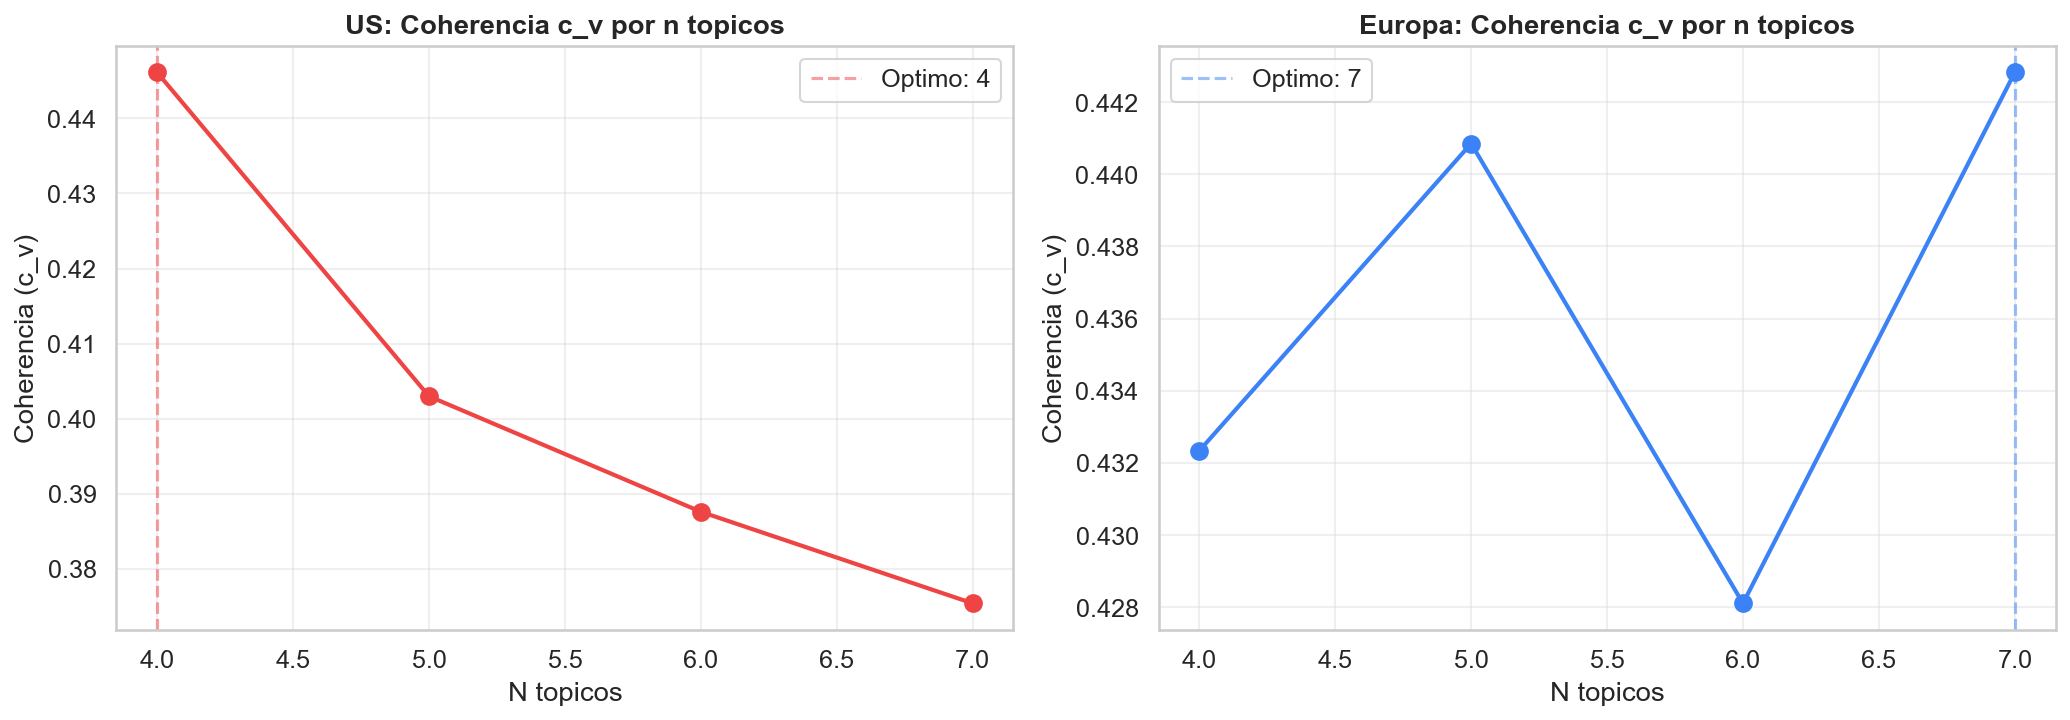

Topicos optimos: US = 4, Europa = 7


In [13]:
# Curva de coherencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns_us = sorted(coherences_us.keys())
vals_us = [coherences_us[n] for n in ns_us]
axes[0].plot(ns_us, vals_us, "o-", color="#EF4444", linewidth=2, markersize=8)
axes[0].axvline(opt_us, color="#EF4444", linestyle="--", alpha=0.5, label=f"Optimo: {opt_us}")
axes[0].set_title("US: Coherencia c_v por n topicos", fontweight="bold")
axes[0].set_xlabel("N topicos")
axes[0].set_ylabel("Coherencia (c_v)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ns_eu = sorted(coherences_eu.keys())
vals_eu = [coherences_eu[n] for n in ns_eu]
axes[1].plot(ns_eu, vals_eu, "o-", color="#3B82F6", linewidth=2, markersize=8)
axes[1].axvline(opt_eu, color="#3B82F6", linestyle="--", alpha=0.5, label=f"Optimo: {opt_eu}")
axes[1].set_title("Europa: Coherencia c_v por n topicos", fontweight="bold")
axes[1].set_xlabel("N topicos")
axes[1].set_ylabel("Coherencia (c_v)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "sent_bertopic_coherencia")
plt.show()
print(f"Topicos optimos: US = {opt_us}, Europa = {opt_eu}")

**Interpretacion:** La curva de coherencia (c_v) mide la calidad semantica de los topicos. El punto optimo es el maximo: mas topicos fragmentan temas, menos topicos mezclan temas distintos. Con los textos traducidos a ingles, la coherencia captura mejor las diferencias entre configuraciones.

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_bertopic_us_vs_europa.png


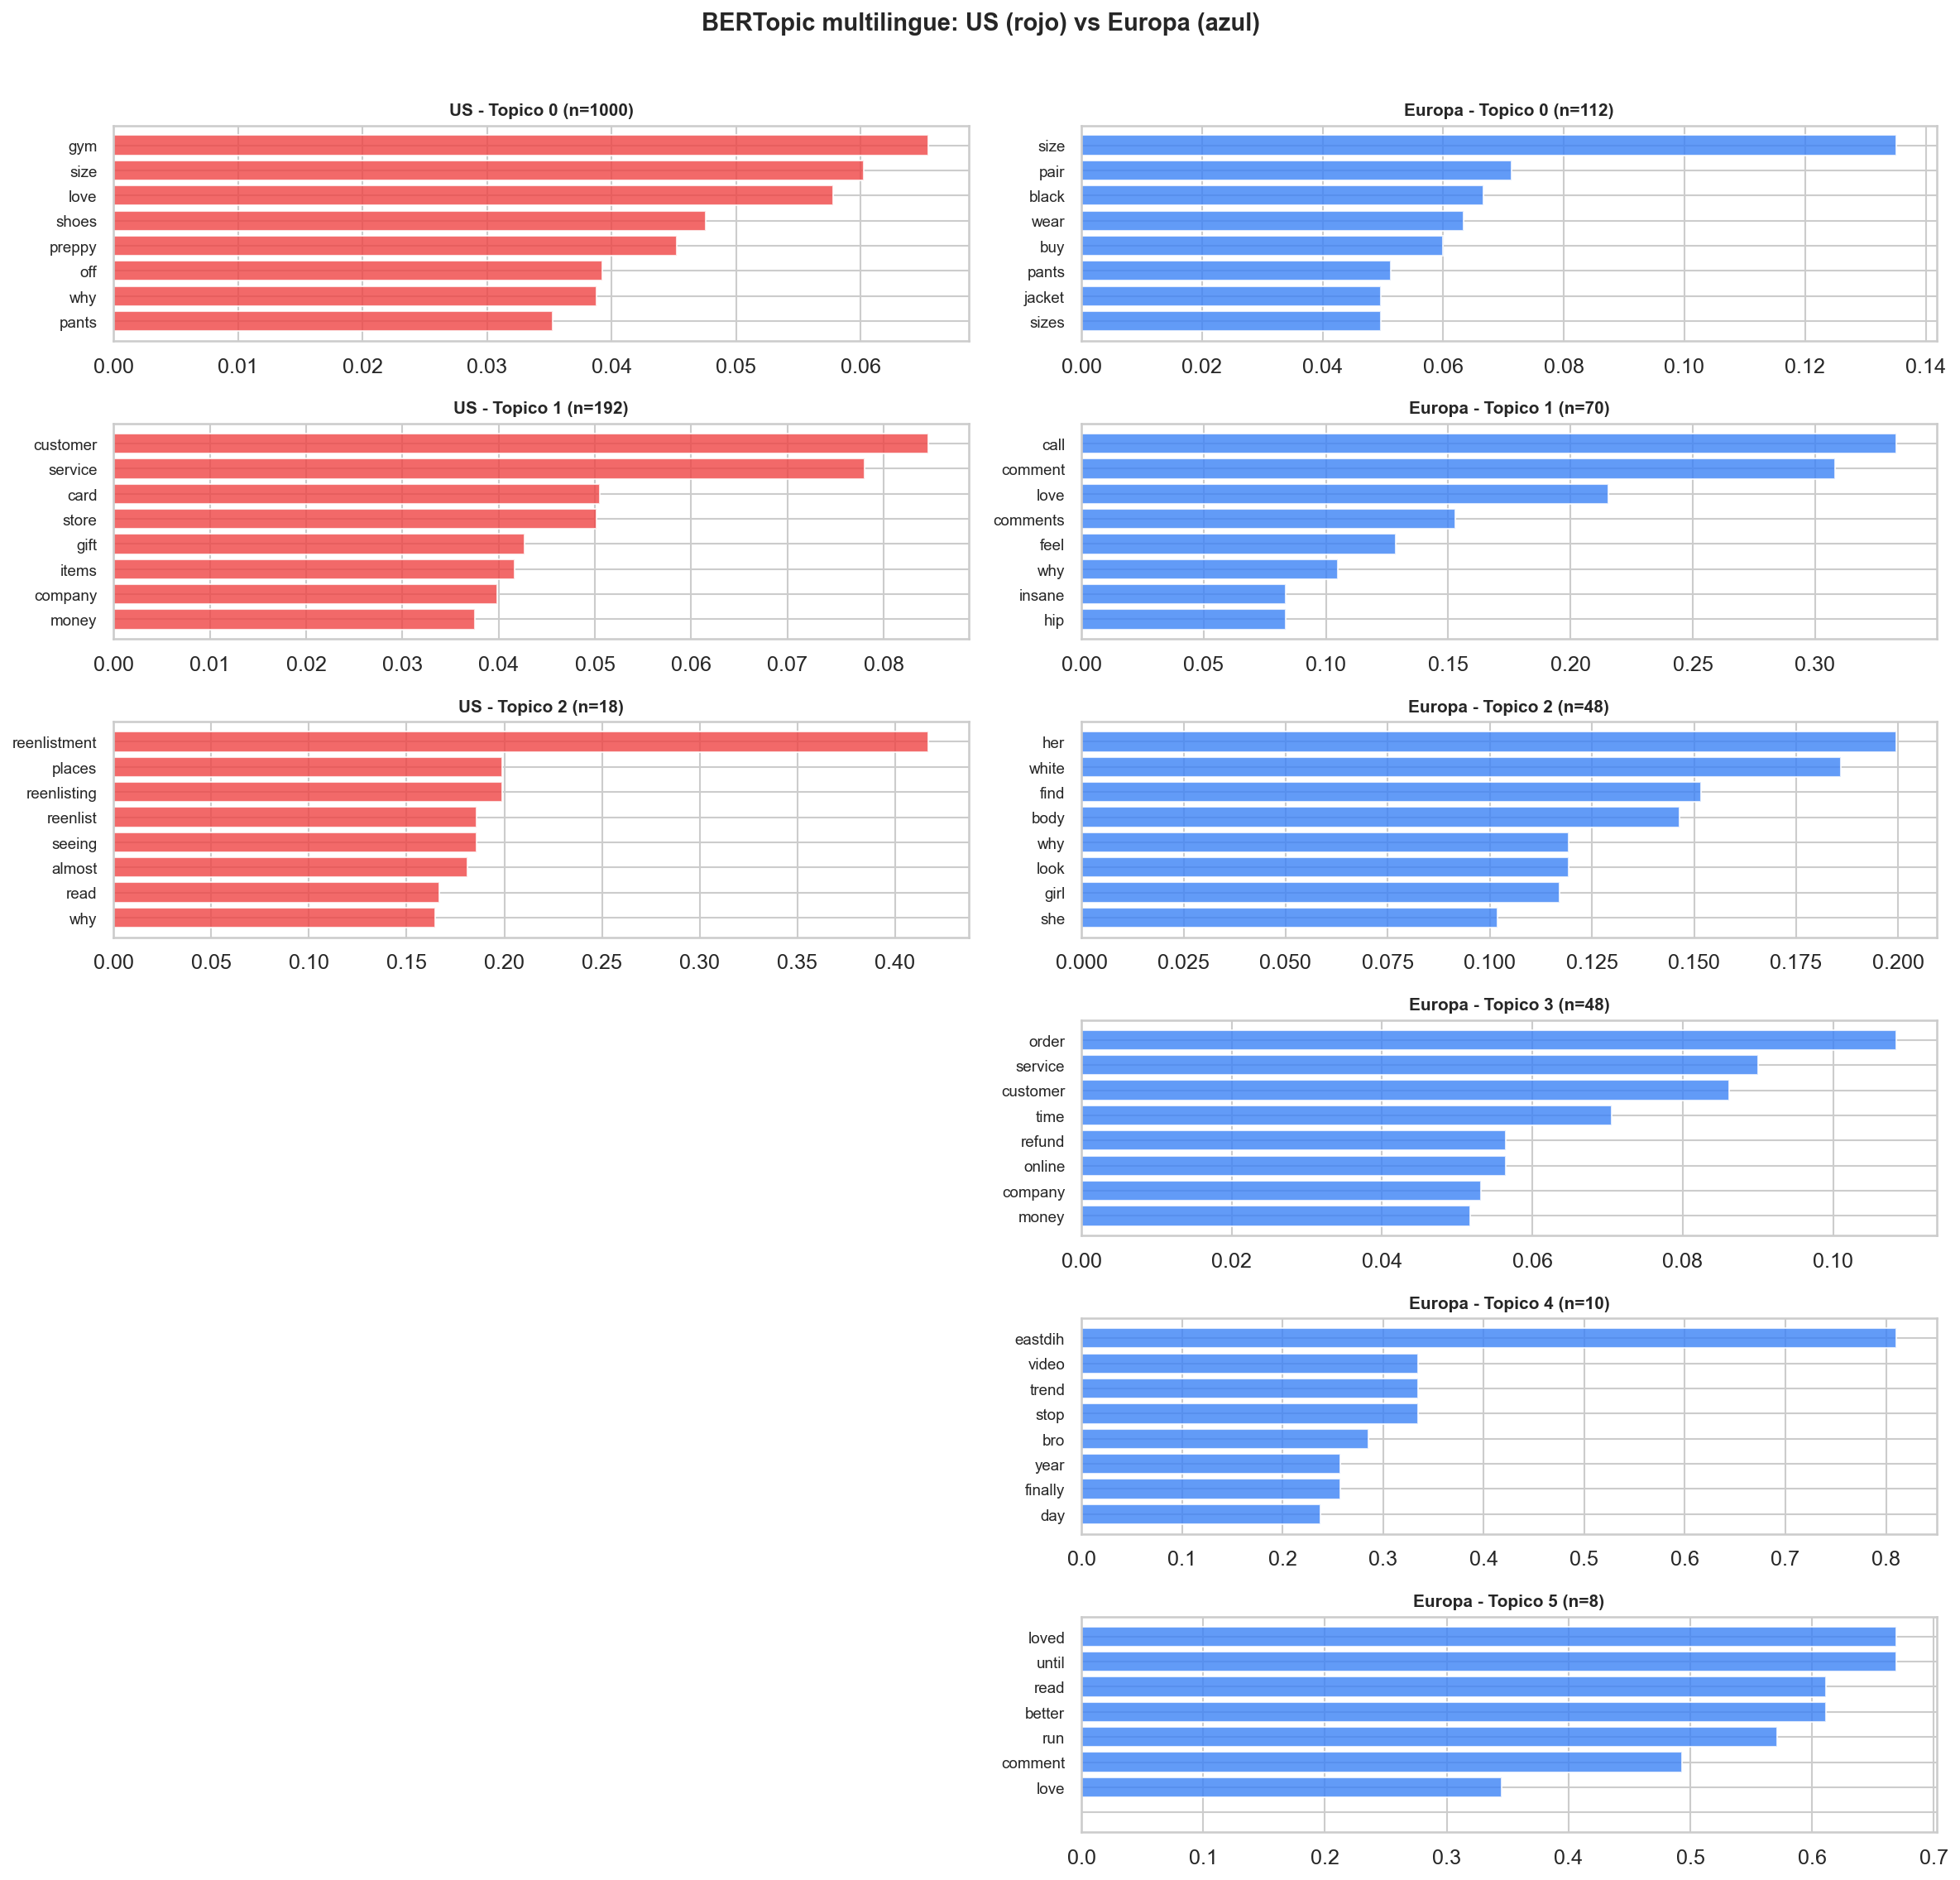

In [14]:
# Visualizar top palabras por topico: US vs Europa
info_us = model_us.get_topic_info()
info_eu = model_eu.get_topic_info()

valid_us = info_us[info_us["Topic"] != -1].head(opt_us)
valid_eu = info_eu[info_eu["Topic"] != -1].head(opt_eu)

n_rows = max(len(valid_us), len(valid_eu))
fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows * 2.5))

for idx in range(n_rows):
    # US
    if idx < len(valid_us):
        tid = valid_us.iloc[idx]["Topic"]
        words_weights = model_us.get_topic(tid)[:8]
        words = [w for w, _ in words_weights]
        weights = [s for _, s in words_weights]
        axes[idx, 0].barh(words[::-1], weights[::-1], color="#EF4444", alpha=0.8)
        axes[idx, 0].set_title(f"US - Topico {tid} (n={valid_us.iloc[idx]['Count']})", fontweight="bold", fontsize=10)
    else:
        axes[idx, 0].axis("off")

    # Europa
    if idx < len(valid_eu):
        tid = valid_eu.iloc[idx]["Topic"]
        words_weights = model_eu.get_topic(tid)[:8]
        words = [w for w, _ in words_weights]
        weights = [s for _, s in words_weights]
        axes[idx, 1].barh(words[::-1], weights[::-1], color="#3B82F6", alpha=0.8)
        axes[idx, 1].set_title(f"Europa - Topico {tid} (n={valid_eu.iloc[idx]['Count']})", fontweight="bold", fontsize=10)
    else:
        axes[idx, 1].axis("off")

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis="y", labelsize=9)

plt.suptitle("BERTopic multilingue: US (rojo) vs Europa (azul)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig(fig, "sent_bertopic_us_vs_europa")
plt.show()

**Interpretacion:** Al usar embeddings multilingues, los topicos europeos agrupan comentarios en distintos idiomas por significado, no por idioma. Esto permite ver los temas reales que preocupan al consumidor europeo sin sesgo linguistico.

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_bertopic_5_topicos.png


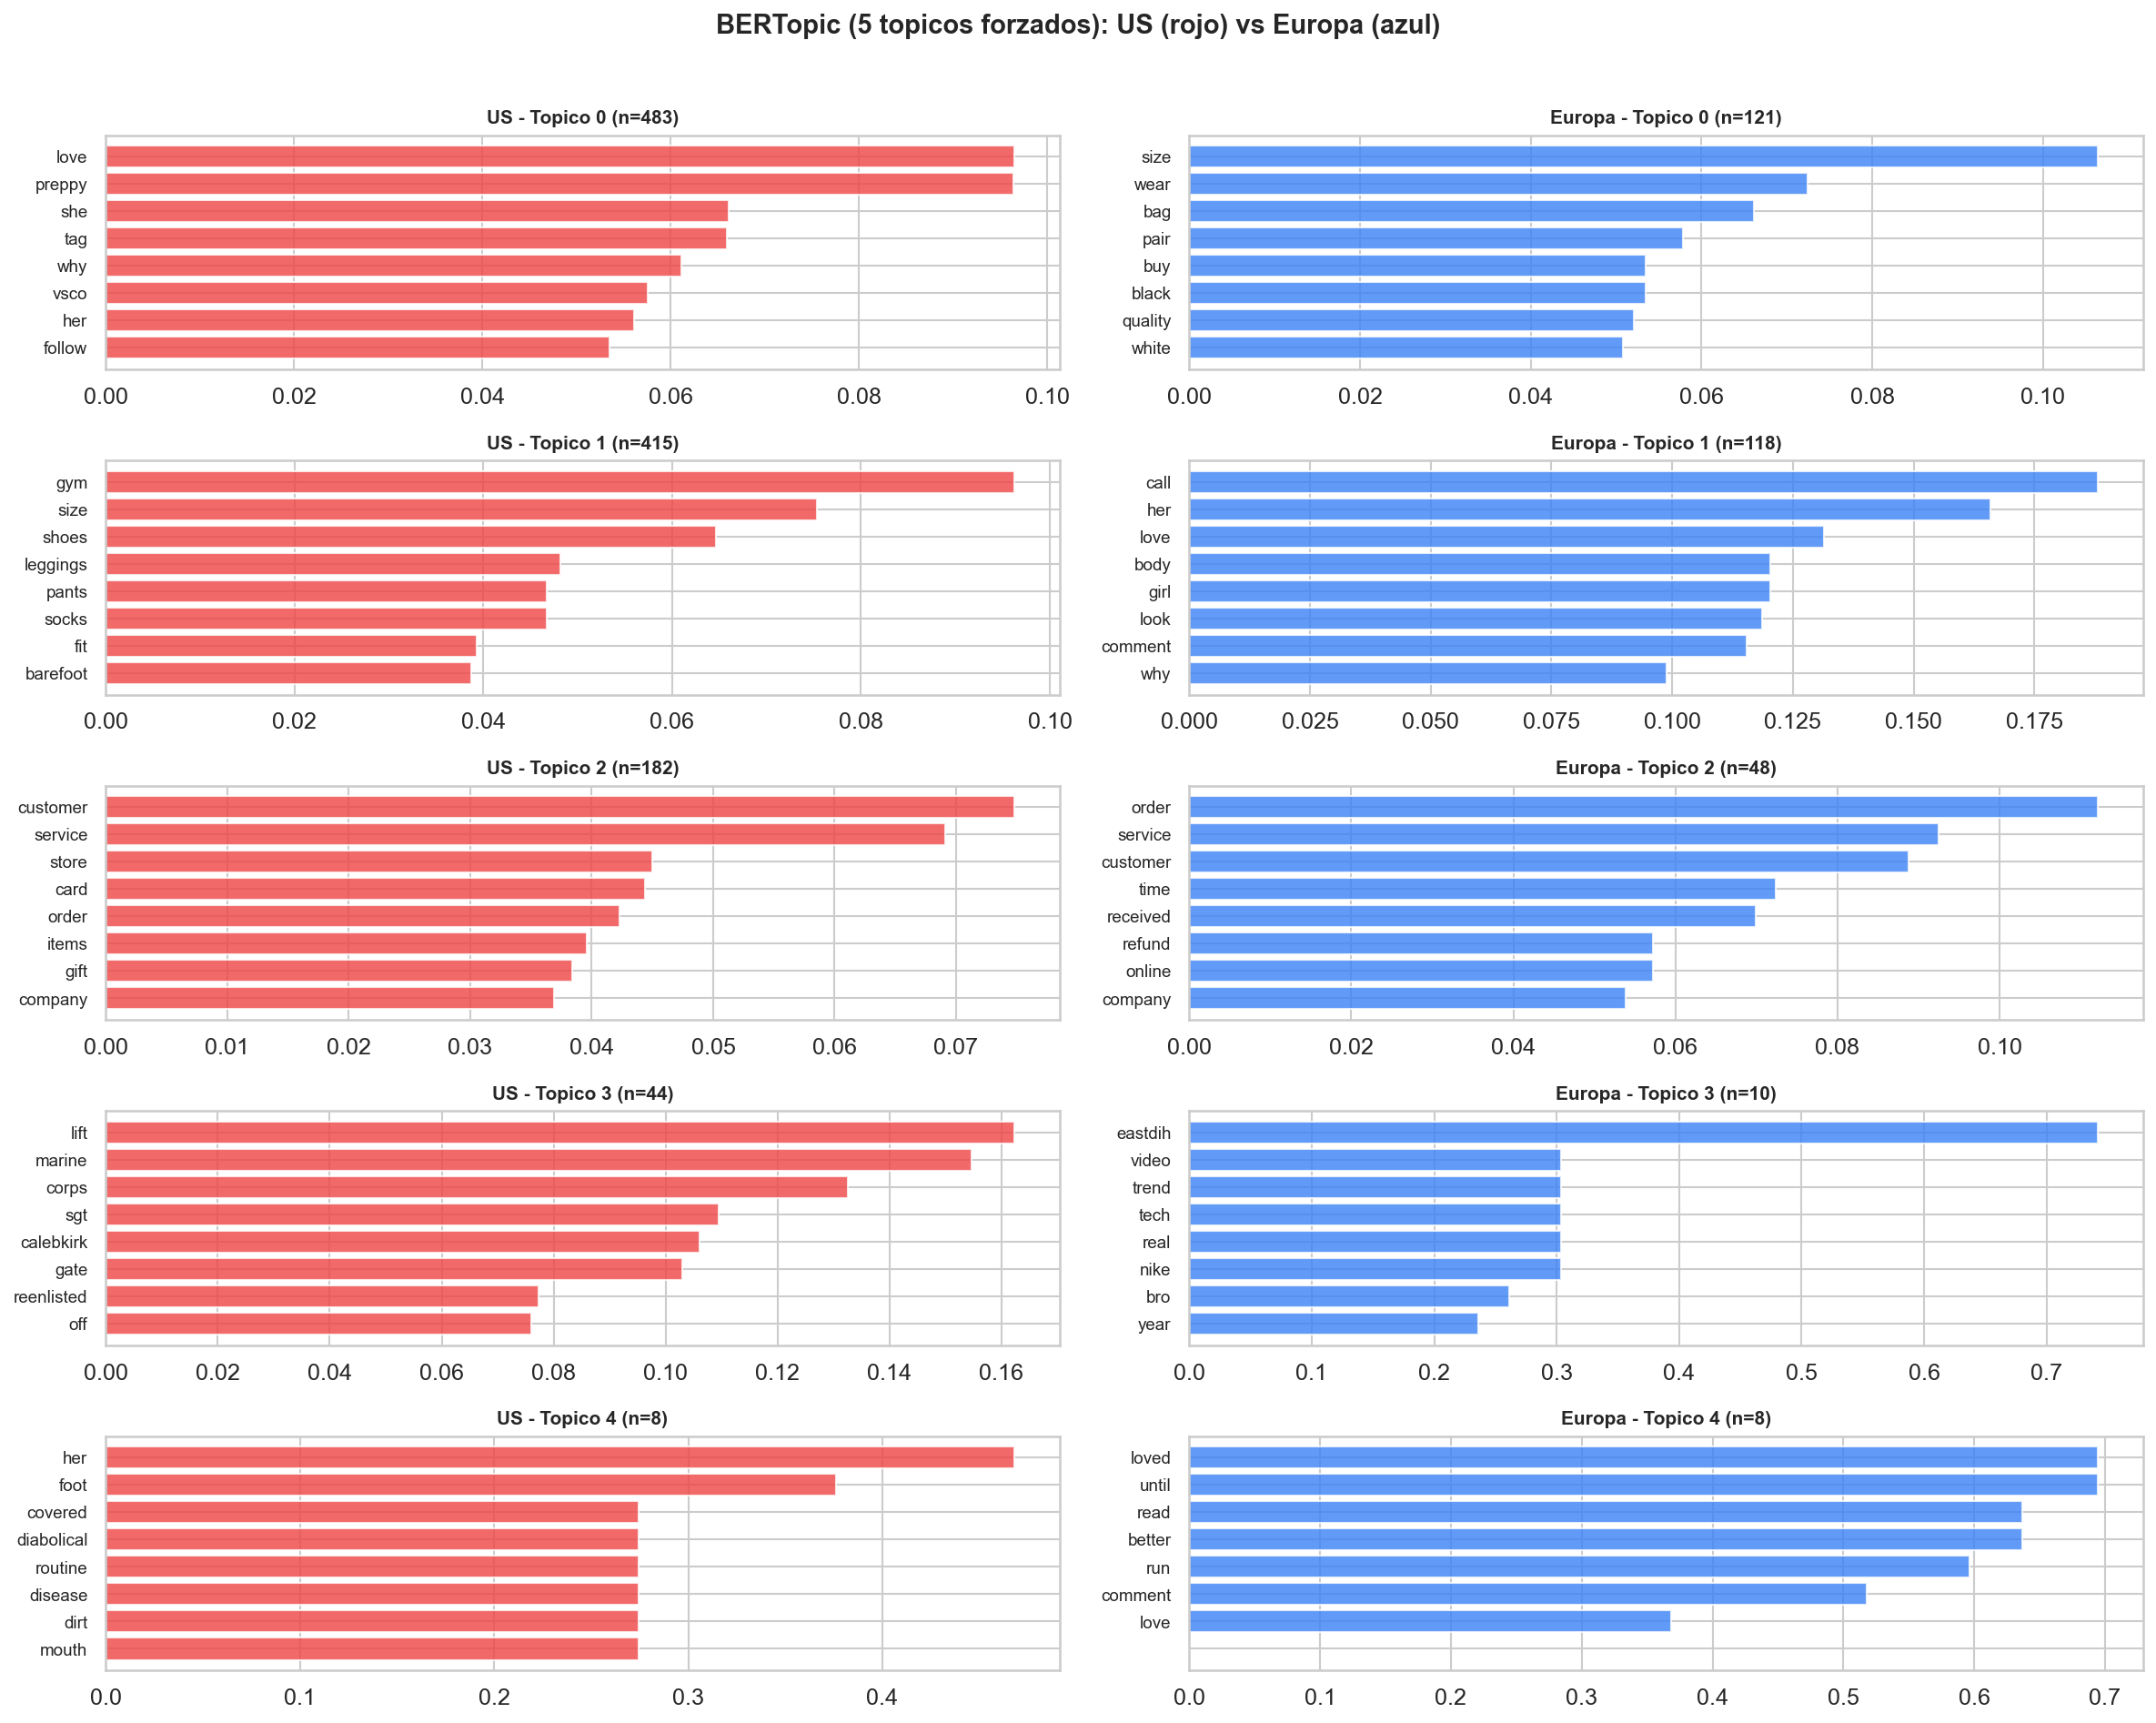

In [15]:
# Visualizar 5 topicos forzados: US vs Europa
info_us5 = model_us_5.get_topic_info()
info_eu5 = model_eu_5.get_topic_info()

valid_us5 = info_us5[info_us5["Topic"] != -1]
valid_eu5 = info_eu5[info_eu5["Topic"] != -1]

n_rows = max(len(valid_us5), len(valid_eu5))
if n_rows == 0:
    print("No hay topicos para visualizar")
else:
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows * 2.5))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx in range(n_rows):
        if idx < len(valid_us5):
            tid = valid_us5.iloc[idx]["Topic"]
            words_weights = model_us_5.get_topic(tid)[:8]
            words = [w for w, _ in words_weights]
            weights = [s for _, s in words_weights]
            axes[idx, 0].barh(words[::-1], weights[::-1], color="#EF4444", alpha=0.8)
            axes[idx, 0].set_title(f"US - Topico {tid} (n={valid_us5.iloc[idx]['Count']})", fontweight="bold", fontsize=10)
        else:
            axes[idx, 0].axis("off")

        if idx < len(valid_eu5):
            tid = valid_eu5.iloc[idx]["Topic"]
            words_weights = model_eu_5.get_topic(tid)[:8]
            words = [w for w, _ in words_weights]
            weights = [s for _, s in words_weights]
            axes[idx, 1].barh(words[::-1], weights[::-1], color="#3B82F6", alpha=0.8)
            axes[idx, 1].set_title(f"Europa - Topico {tid} (n={valid_eu5.iloc[idx]['Count']})", fontweight="bold", fontsize=10)
        else:
            axes[idx, 1].axis("off")

    for ax_row in axes:
        for ax in ax_row:
            ax.tick_params(axis="y", labelsize=9)

    plt.suptitle("BERTopic (5 topicos forzados): US (rojo) vs Europa (azul)", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    save_fig(fig, "sent_bertopic_5_topicos")
    plt.show()

**Interpretacion:** Este segundo analisis fuerza 5 topicos por region para garantizar granularidad comparable. Permite comparar directamente US vs Europa con el mismo nivel de detalle, evitando que una region tenga demasiados pocos topicos por limitaciones de muestra.

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_bertopic_5_plataforma.png


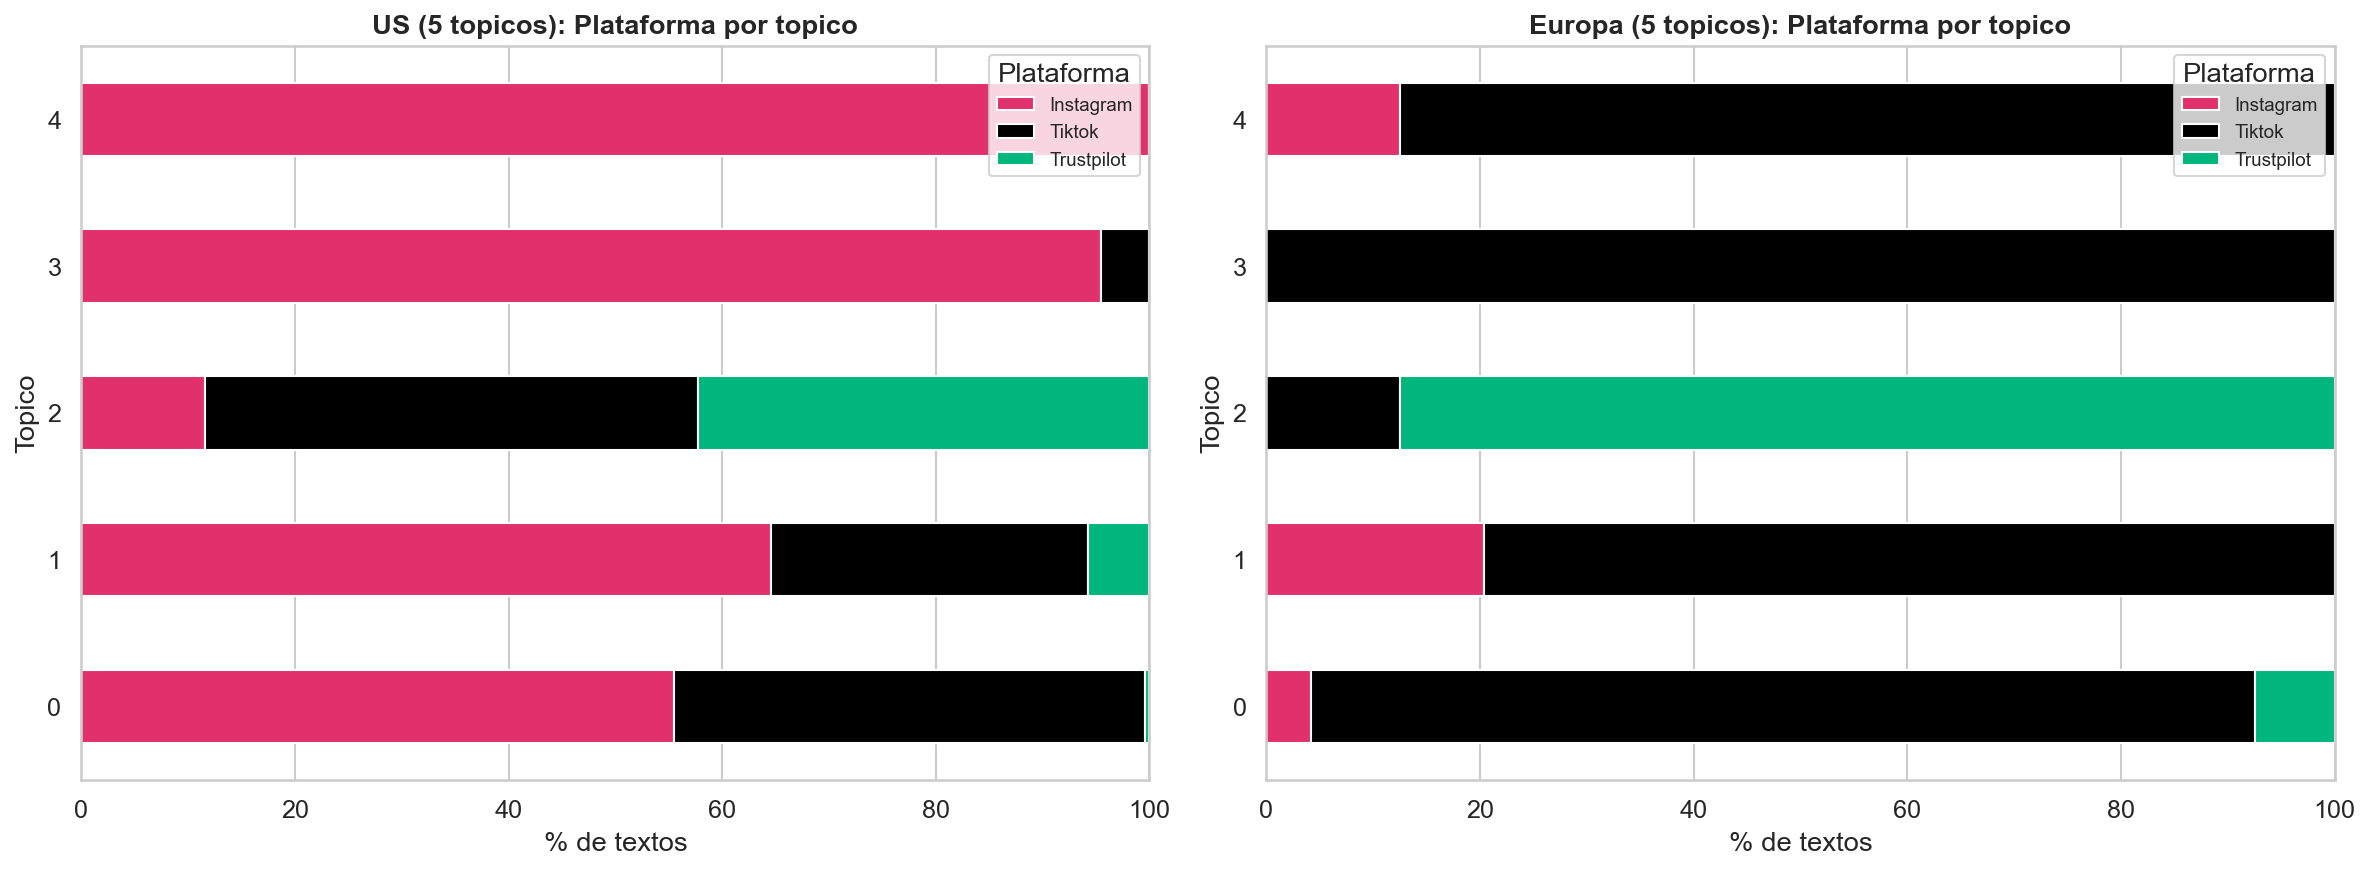

TOPICOS US (5 forzados): palabras clave y presencia por plataforma
  Topico 0 (n=483): love, preppy, she, tag, why, vsco
    -> Instagram: 55% | Tiktok: 44% | Trustpilot: 0%
  Topico 1 (n=415): gym, size, shoes, leggings, pants, socks
    -> Instagram: 65% | Tiktok: 30% | Trustpilot: 6%
  Topico 2 (n=182): customer, service, store, card, order, items
    -> Instagram: 12% | Tiktok: 46% | Trustpilot: 42%
  Topico 3 (n=44): lift, marine, corps, sgt, calebkirk, gate
    -> Instagram: 95% | Tiktok: 5% | Trustpilot: 0%
  Topico 4 (n=8): her, foot, covered, diabolical, routine, disease
    -> Instagram: 100% | Tiktok: 0% | Trustpilot: 0%
TOPICOS EUROPA (5 forzados): palabras clave y presencia por plataforma
  Topico 0 (n=121): size, wear, bag, pair, buy, black
    -> Instagram: 4% | Tiktok: 88% | Trustpilot: 7%
  Topico 1 (n=118): call, her, love, body, girl, look
    -> Instagram: 20% | Tiktok: 80% | Trustpilot: 0%
  Topico 2 (n=48): order, service, customer, time, received, refund
    -> I

In [16]:
# Presencia por plataforma: 5 topicos forzados
us5_valid = texts_us_clean[texts_us_clean["topico_5"] != -1].copy()
eu5_valid = texts_eu_clean[texts_eu_clean["topico_5"] != -1].copy()

cross_us5 = pd.crosstab(us5_valid["topico_5"], us5_valid["platform"], normalize="index") * 100
cross_us5.columns = [c.capitalize() for c in cross_us5.columns]
cross_eu5 = pd.crosstab(eu5_valid["topico_5"], eu5_valid["platform"], normalize="index") * 100
cross_eu5.columns = [c.capitalize() for c in cross_eu5.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plat_colors_us = [PLATFORM_COLORS.get(p.lower(), "#999") for p in cross_us5.columns]
cross_us5.plot(kind="barh", stacked=True, ax=axes[0], color=plat_colors_us)
axes[0].set_title("US (5 topicos): Plataforma por topico", fontweight="bold")
axes[0].set_xlabel("% de textos")
axes[0].set_ylabel("Topico")
axes[0].legend(title="Plataforma", fontsize=9)

plat_colors_eu = [PLATFORM_COLORS.get(p.lower(), "#999") for p in cross_eu5.columns]
cross_eu5.plot(kind="barh", stacked=True, ax=axes[1], color=plat_colors_eu)
axes[1].set_title("Europa (5 topicos): Plataforma por topico", fontweight="bold")
axes[1].set_xlabel("% de textos")
axes[1].set_ylabel("Topico")
axes[1].legend(title="Plataforma", fontsize=9)

plt.tight_layout()
save_fig(fig, "sent_bertopic_5_plataforma")
plt.show()

# Tabla resumen
print("" + "="*90)
print("TOPICOS US (5 forzados): palabras clave y presencia por plataforma")
print("="*90)
for _, row in valid_us5.iterrows():
    tid = row["Topic"]
    words = ", ".join([w for w, _ in model_us_5.get_topic(tid)[:6]])
    subset = us5_valid[us5_valid["topico_5"] == tid]
    plat_pct = subset["platform"].value_counts(normalize=True) * 100
    plat_str = " | ".join([f"{p.capitalize()}: {plat_pct.get(p, 0):.0f}%" for p in ["instagram", "tiktok", "trustpilot"]])
    print(f"  Topico {tid} (n={len(subset)}): {words}")
    print(f"    -> {plat_str}")

print("" + "="*90)
print("TOPICOS EUROPA (5 forzados): palabras clave y presencia por plataforma")
print("="*90)
for _, row in valid_eu5.iterrows():
    tid = row["Topic"]
    words = ", ".join([w for w, _ in model_eu_5.get_topic(tid)[:6]])
    subset = eu5_valid[eu5_valid["topico_5"] == tid]
    plat_pct = subset["platform"].value_counts(normalize=True) * 100
    plat_str = " | ".join([f"{p.capitalize()}: {plat_pct.get(p, 0):.0f}%" for p in ["instagram", "tiktok", "trustpilot"]])
    print(f"  Topico {tid} (n={len(subset)}): {words}")
    print(f"    -> {plat_str}")

### 6.2 Presencia de cada topico por plataforma y region

Para cada region se muestra en que red social (Instagram, TikTok, Trustpilot) aparece cada topico.

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_bertopic_plataforma_region.png


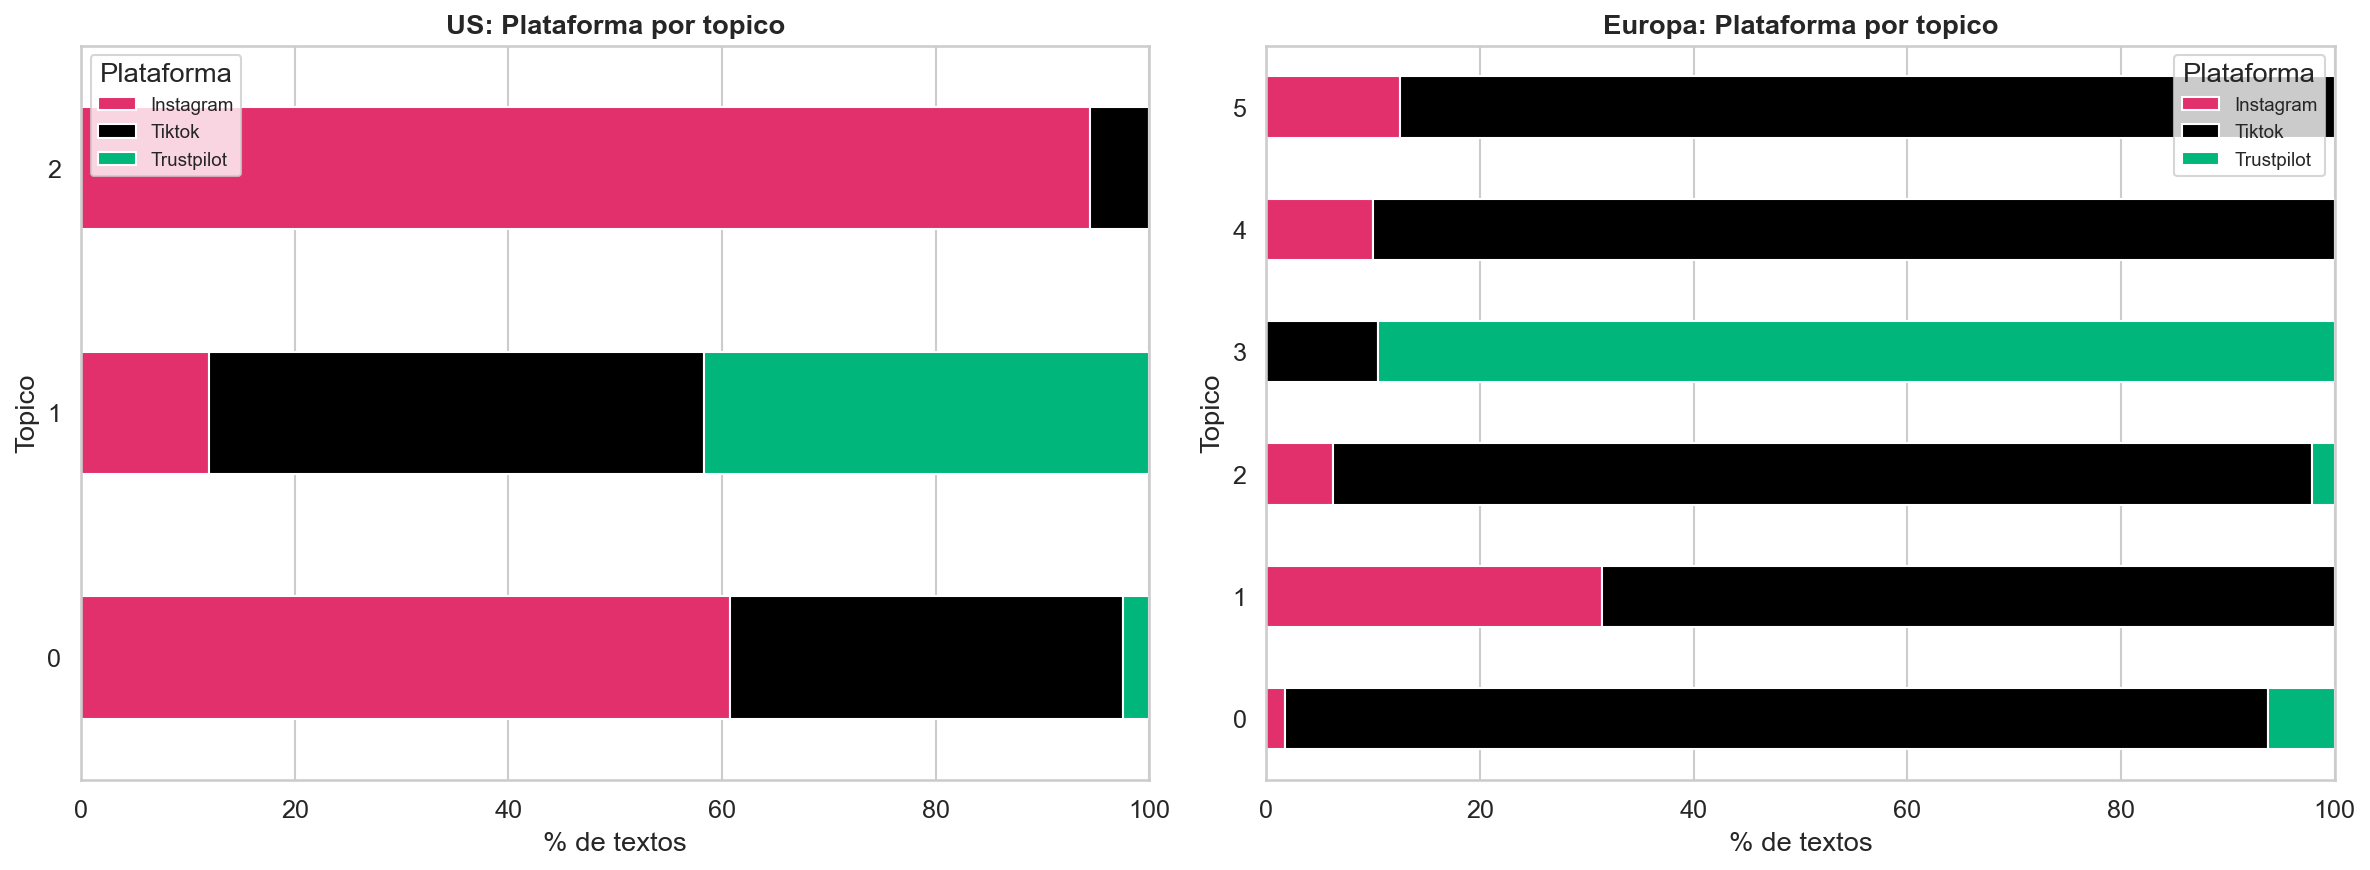

In [17]:
# Filtrar outliers (topico -1 = sin topico claro)
us_valid = texts_us_clean[texts_us_clean["topico"] != -1].copy()
eu_valid = texts_eu_clean[texts_eu_clean["topico"] != -1].copy()

# Cruce topico x plataforma para cada region
cross_us = pd.crosstab(us_valid["topico"], us_valid["platform"], normalize="index") * 100
cross_us.columns = [c.capitalize() for c in cross_us.columns]

cross_eu = pd.crosstab(eu_valid["topico"], eu_valid["platform"], normalize="index") * 100
cross_eu.columns = [c.capitalize() for c in cross_eu.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plat_colors = [PLATFORM_COLORS.get(p.lower(), "#999") for p in cross_us.columns]

cross_us.plot(kind="barh", stacked=True, ax=axes[0], color=plat_colors)
axes[0].set_title("US: Plataforma por topico", fontweight="bold")
axes[0].set_xlabel("% de textos")
axes[0].set_ylabel("Topico")
axes[0].legend(title="Plataforma", fontsize=9)

plat_colors_eu = [PLATFORM_COLORS.get(p.lower(), "#999") for p in cross_eu.columns]
cross_eu.plot(kind="barh", stacked=True, ax=axes[1], color=plat_colors_eu)
axes[1].set_title("Europa: Plataforma por topico", fontweight="bold")
axes[1].set_xlabel("% de textos")
axes[1].set_ylabel("Topico")
axes[1].legend(title="Plataforma", fontsize=9)

plt.tight_layout()
save_fig(fig, "sent_bertopic_plataforma_region")
plt.show()

In [18]:
# Tabla resumen detallada
print("=" * 90)
print("TOPICOS US: palabras clave y presencia por plataforma")
print("=" * 90)
for _, row in valid_us.iterrows():
    tid = row["Topic"]
    words = ", ".join([w for w, _ in model_us.get_topic(tid)[:6]])
    subset = us_valid[us_valid["topico"] == tid]
    n = len(subset)
    plat_pct = subset["platform"].value_counts(normalize=True) * 100
    plat_str = " | ".join([f"{p.capitalize()}: {plat_pct.get(p, 0):.0f}%" for p in ["instagram", "tiktok", "trustpilot"]])
    print(f"  Topico {tid} (n={n}): {words}")
    print(f"    -> {plat_str}")

print()
print("=" * 90)
print("TOPICOS EUROPA: palabras clave y presencia por plataforma")
print("=" * 90)
for _, row in valid_eu.iterrows():
    tid = row["Topic"]
    words = ", ".join([w for w, _ in model_eu.get_topic(tid)[:6]])
    subset = eu_valid[eu_valid["topico"] == tid]
    n = len(subset)
    plat_pct = subset["platform"].value_counts(normalize=True) * 100
    plat_str = " | ".join([f"{p.capitalize()}: {plat_pct.get(p, 0):.0f}%" for p in ["instagram", "tiktok", "trustpilot"]])
    print(f"  Topico {tid} (n={n}): {words}")
    print(f"    -> {plat_str}")

TOPICOS US: palabras clave y presencia por plataforma
  Topico 0 (n=1000): gym, size, love, shoes, preppy, off
    -> Instagram: 61% | Tiktok: 37% | Trustpilot: 2%
  Topico 1 (n=192): customer, service, card, store, gift, items
    -> Instagram: 12% | Tiktok: 46% | Trustpilot: 42%
  Topico 2 (n=18): reenlistment, places, reenlisting, reenlist, seeing, almost
    -> Instagram: 94% | Tiktok: 6% | Trustpilot: 0%

TOPICOS EUROPA: palabras clave y presencia por plataforma
  Topico 0 (n=112): size, pair, black, wear, buy, pants
    -> Instagram: 2% | Tiktok: 92% | Trustpilot: 6%
  Topico 1 (n=70): call, comment, love, comments, feel, why
    -> Instagram: 31% | Tiktok: 69% | Trustpilot: 0%
  Topico 2 (n=48): her, white, find, body, why, look
    -> Instagram: 6% | Tiktok: 92% | Trustpilot: 2%
  Topico 3 (n=48): order, service, customer, time, refund, online
    -> Instagram: 0% | Tiktok: 10% | Trustpilot: 90%
  Topico 4 (n=10): eastdih, video, trend, stop, bro, year
    -> Instagram: 10% | T

**Interpretacion:** Esta tabla permite ver de un vistazo donde vive cada tema. Si un topico sobre problemas de envio aparece mayoritariamente en Trustpilot, es un canal de queja directa. Si un topico lifestyle domina en Instagram/TikTok, refleja el posicionamiento aspiracional. Las diferencias entre US y Europa revelan prioridades distintas por mercado.

In [19]:
# Guardar topicos regionales
rows = []
for _, r in valid_us.iterrows():
    tid = r["Topic"]
    words = [w for w, _ in model_us.get_topic(tid)[:8]]
    subset = us_valid[us_valid["topico"] == tid]
    plat_pct = subset["platform"].value_counts(normalize=True) * 100
    rows.append({
        "region": "US", "topico": tid, "n_docs": len(subset),
        "palabras": ", ".join(words),
        "pct_instagram": round(plat_pct.get("instagram", 0), 1),
        "pct_tiktok": round(plat_pct.get("tiktok", 0), 1),
        "pct_trustpilot": round(plat_pct.get("trustpilot", 0), 1),
    })

for _, r in valid_eu.iterrows():
    tid = r["Topic"]
    words = [w for w, _ in model_eu.get_topic(tid)[:8]]
    subset = eu_valid[eu_valid["topico"] == tid]
    plat_pct = subset["platform"].value_counts(normalize=True) * 100
    rows.append({
        "region": "Europa", "topico": tid, "n_docs": len(subset),
        "palabras": ", ".join(words),
        "pct_instagram": round(plat_pct.get("instagram", 0), 1),
        "pct_tiktok": round(plat_pct.get("tiktok", 0), 1),
        "pct_trustpilot": round(plat_pct.get("trustpilot", 0), 1),
    })

df_topics = pd.DataFrame(rows)
df_topics.to_csv("../../outputs/tablas/sent_bertopic_por_region.csv", index=False)
print("Guardado: outputs/tablas/sent_bertopic_por_region.csv")
df_topics

Guardado: outputs/tablas/sent_bertopic_por_region.csv


,region,topico,n_docs,palabras,pct_instagram,pct_tiktok,pct_trustpilot
0,US,0,1000,"gym, size, love, shoes, preppy, off, why, pants",60.7,36.8,2.5
1,US,1,192,"customer, service, card, store, gift, items, c...",12.0,46.4,41.7
2,US,2,18,"reenlistment, places, reenlisting, reenlist, s...",94.4,5.6,0.0
3,Europa,0,112,"size, pair, black, wear, buy, pants, jacket, s...",1.8,92.0,6.2
4,Europa,1,70,"call, comment, love, comments, feel, why, insa...",31.4,68.6,0.0
5,Europa,2,48,"her, white, find, body, why, look, girl, she",6.2,91.7,2.1
6,Europa,3,48,"order, service, customer, time, refund, online...",0.0,10.4,89.6
7,Europa,4,10,"eastdih, video, trend, stop, bro, year, finall...",10.0,90.0,0.0
8,Europa,5,8,"loved, until, read, better, run, comment, love,",12.5,87.5,0.0


### 6.3 Sentimiento por topico y region

Analisis del sentimiento dominante en cada topico, separado por US y Europa (modelo de 5 topicos forzados).

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_sentimiento_por_topico_region.png


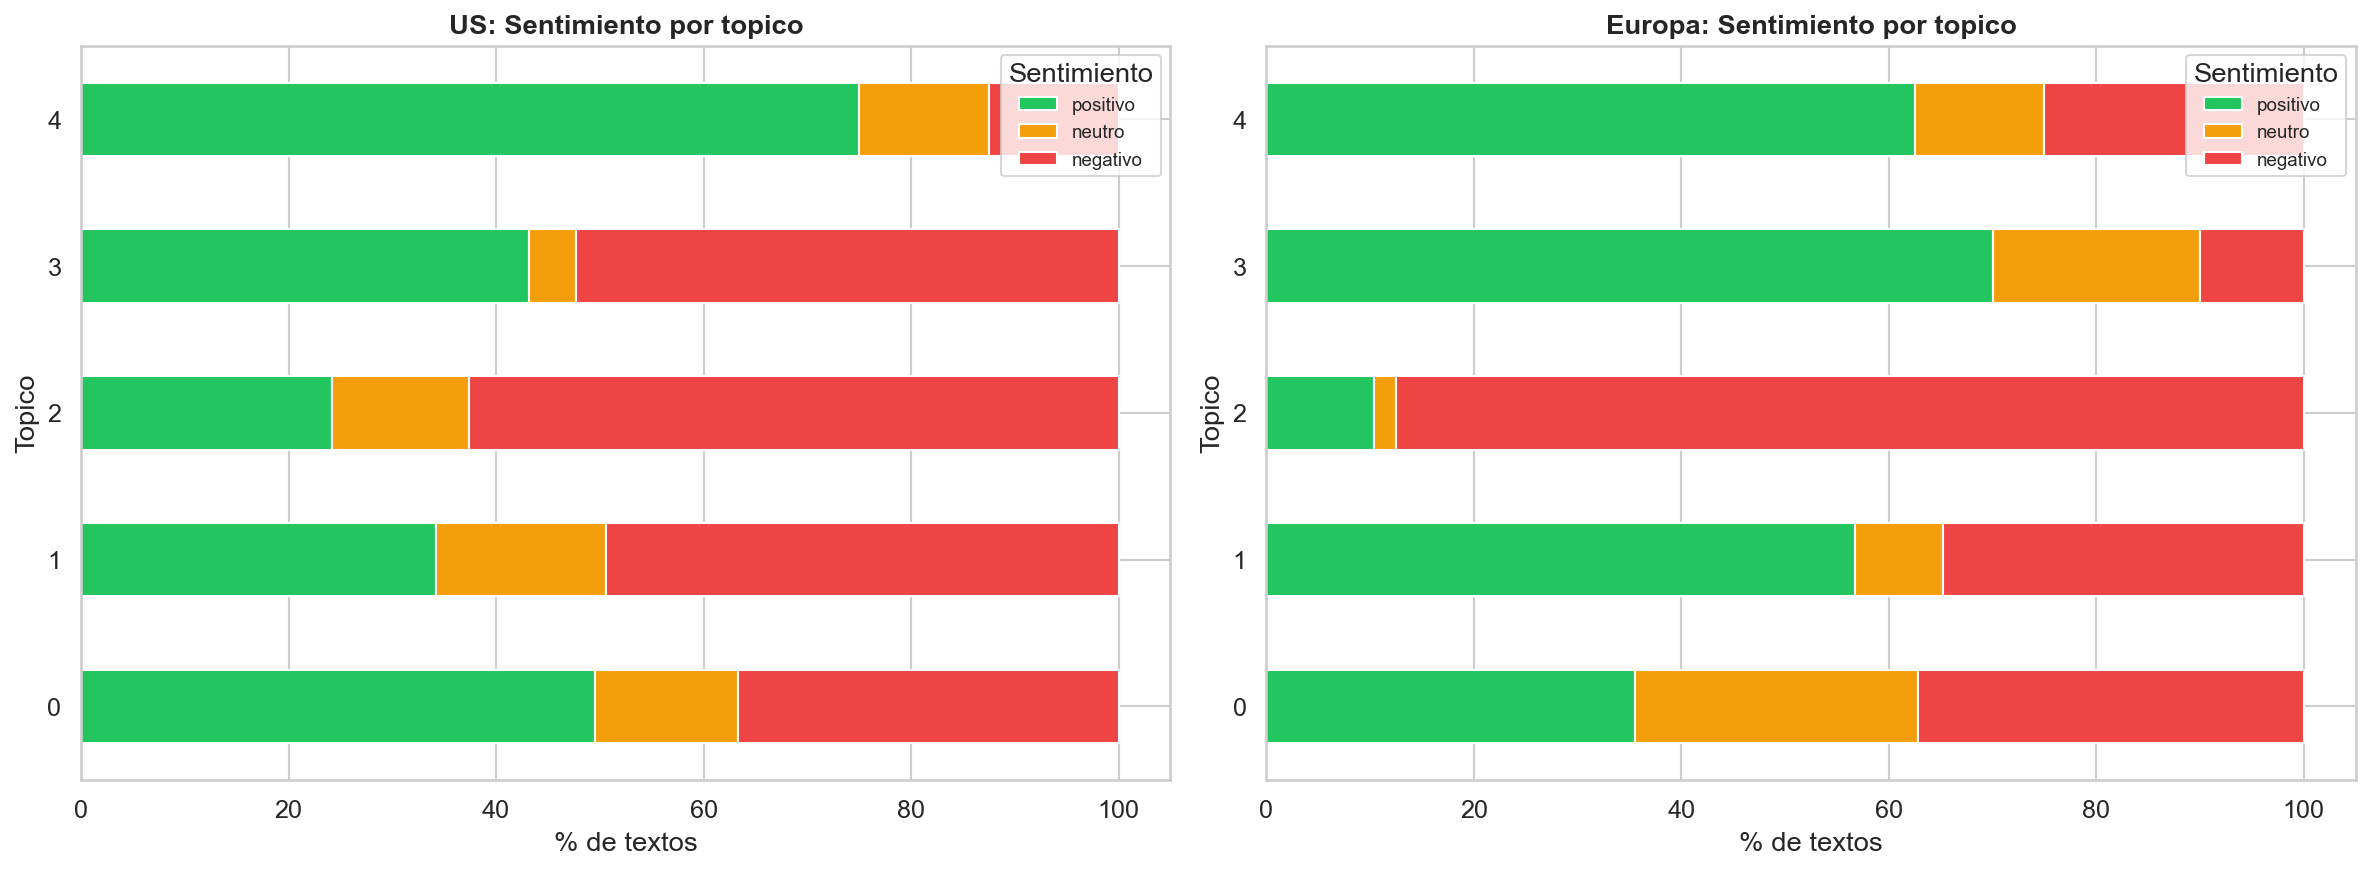

SENTIMIENTO POR TOPICO - US
------------------------------------------------------------
  T0 (483 docs): love, preppy, she, tag, why
    +49% / -37% / media: 3.2 estrellas
  T1 (415 docs): gym, size, shoes, leggings, pants
    +34% / -49% / media: 2.7 estrellas
  T2 (182 docs): customer, service, store, card, order
    +24% / -63% / media: 2.2 estrellas
  T3 (44 docs): lift, marine, corps, sgt, calebkirk
    +43% / -52% / media: 2.9 estrellas
  T4 (8 docs): her, foot, covered, diabolical, routine
    +75% / -12% / media: 4.0 estrellas

SENTIMIENTO POR TOPICO - EUROPA
------------------------------------------------------------
  T0 (121 docs): size, wear, bag, pair, buy
    +36% / -37% / media: 2.9 estrellas
  T1 (118 docs): call, her, love, body, girl
    +57% / -35% / media: 3.4 estrellas
  T2 (48 docs): order, service, customer, time, received
    +10% / -88% / media: 1.6 estrellas
  T3 (10 docs): eastdih, video, trend, tech, real
    +70% / -10% / media: 3.8 estrellas
  T4 (8 docs

In [20]:
# Sentimiento por topico - US
us5 = texts_us_clean[texts_us_clean["topico_5"] != -1].copy()
eu5 = texts_eu_clean[texts_eu_clean["topico_5"] != -1].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# US: sentimiento por topico
cross_sent_us = pd.crosstab(us5["topico_5"], us5["sentiment_label"], normalize="index") * 100
sent_order = ["positivo", "neutro", "negativo"]
sent_colors = [COLORS["positive"], COLORS["neutral"], COLORS["negative"]]
cross_sent_us[sent_order].plot(kind="barh", stacked=True, ax=axes[0], color=sent_colors)
axes[0].set_title("US: Sentimiento por topico", fontweight="bold")
axes[0].set_xlabel("% de textos")
axes[0].set_ylabel("Topico")
axes[0].legend(title="Sentimiento", fontsize=9)

# Europa: sentimiento por topico
cross_sent_eu = pd.crosstab(eu5["topico_5"], eu5["sentiment_label"], normalize="index") * 100
cross_sent_eu[sent_order].plot(kind="barh", stacked=True, ax=axes[1], color=sent_colors)
axes[1].set_title("Europa: Sentimiento por topico", fontweight="bold")
axes[1].set_xlabel("% de textos")
axes[1].set_ylabel("Topico")
axes[1].legend(title="Sentimiento", fontsize=9)

plt.tight_layout()
save_fig(fig, "sent_sentimiento_por_topico_region")
plt.show()

# Tabla resumen
print("SENTIMIENTO POR TOPICO - US")
print("-" * 60)
for tid in sorted(us5["topico_5"].unique()):
    subset = us5[us5["topico_5"] == tid]
    words = ", ".join([w for w, _ in model_us_5.get_topic(tid)[:5]])
    pct_pos = (subset["sentiment_label"] == "positivo").mean() * 100
    pct_neg = (subset["sentiment_label"] == "negativo").mean() * 100
    avg_stars = subset["sentiment_stars"].mean()
    print(f"  T{tid} ({len(subset)} docs): {words}")
    print(f"    +{pct_pos:.0f}% / -{pct_neg:.0f}% / media: {avg_stars:.1f} estrellas")

print()
print("SENTIMIENTO POR TOPICO - EUROPA")
print("-" * 60)
for tid in sorted(eu5["topico_5"].unique()):
    subset = eu5[eu5["topico_5"] == tid]
    words = ", ".join([w for w, _ in model_eu_5.get_topic(tid)[:5]])
    pct_pos = (subset["sentiment_label"] == "positivo").mean() * 100
    pct_neg = (subset["sentiment_label"] == "negativo").mean() * 100
    avg_stars = subset["sentiment_stars"].mean()
    print(f"  T{tid} ({len(subset)} docs): {words}")
    print(f"    +{pct_pos:.0f}% / -{pct_neg:.0f}% / media: {avg_stars:.1f} estrellas")

**Interpretacion:** El cruce topico x sentimiento revela que temas generan mas insatisfaccion. Topicos sobre servicio al cliente o envio suelen tener mayor porcentaje de sentimiento negativo, mientras que topicos sobre lifestyle/producto tienden a ser mas positivos.

### 6.4 Deep dive: topicos principales

Para los topicos con mas documentos se extraen **n-gramas** (bigramas y trigramas) y los **top 3 comentarios con mas likes** como ejemplos representativos para la presentacion.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer as CV
from collections import Counter

def deep_dive_topic(df, model, tid, region_name, n_top_comments=3):
    """Deep dive de un topico: n-gramas + top comentarios."""
    subset = df[df["topico_5"] == tid].copy()
    if len(subset) == 0:
        return

    words = ", ".join([w for w, _ in model.get_topic(tid)[:6]])
    print(f"{'='*80}")
    print(f"{region_name} - Topico {tid} ({len(subset)} docs): {words}")
    print(f"{'='*80}")

    # N-gramas (bigramas y trigramas)
    texts = subset["text_en"].dropna().tolist()
    for n, label in [(2, "Bigramas"), (3, "Trigramas")]:
        try:
            vec = CV(ngram_range=(n, n), stop_words="english", min_df=2, max_features=500,
                     token_pattern=r'\b[a-zA-Z]{3,}\b')
            X = vec.fit_transform(texts)
            freqs = zip(vec.get_feature_names_out(), X.sum(axis=0).A1)
            top = sorted(freqs, key=lambda x: x[1], reverse=True)[:10]
            print(f"\n  {label} mas frecuentes:")
            for gram, count in top:
                print(f"    {gram}: {int(count)}")
        except:
            print(f"\n  {label}: no hay suficientes datos")

    # Top comentarios por likes
    if "likes" in subset.columns:
        top_comments = subset.nlargest(n_top_comments, "likes")
    else:
        top_comments = subset.head(n_top_comments)

    print(f"\n  Top {n_top_comments} comentarios (por likes):")
    for _, row in top_comments.iterrows():
        likes = row.get("likes", "?")
        text = str(row.get("text_en", row.get("text_clean", "")))[:200]
        platform = row.get("platform", "?")
        sent = row.get("sentiment_label", "?")
        print(f"    [{platform}] ({likes} likes, {sent}) {text}")
    print()

# Top 3 topicos por n docs en cada region
print("DEEP DIVE: TOPICOS PRINCIPALES\n")

us5_counts = us5["topico_5"].value_counts()
eu5_counts = eu5["topico_5"].value_counts()

top_us_topics = us5_counts.head(3).index.tolist()
top_eu_topics = eu5_counts.head(3).index.tolist()

for tid in top_us_topics:
    deep_dive_topic(us5, model_us_5, tid, "US")

for tid in top_eu_topics:
    deep_dive_topic(eu5, model_eu_5, tid, "EUROPA")

DEEP DIVE: TOPICOS PRINCIPALES

US - Topico 0 (483 docs): love, preppy, she, tag, why, vsco

  Bigramas mas frecuentes:
    send links: 9
    polka dots: 6
    preppy vsco: 6
    lulu lemon: 4
    tag follow: 4
    dont know: 3
    lemon logo: 3
    love link: 3
    love send: 3
    new preppy: 3

  Trigramas mas frecuentes:
    lulu lemon logo: 3
    amiraalfahmawi thats old: 2
    bum bum cream: 2
    check story giveaway: 2
    follow check story: 2
    love send links: 2
    love tag comes: 2
    preppy new preppy: 2
    thats old preppy: 2

  Top 3 comentarios (por likes):
    [instagram] (? likes, positivo) I promise this reel makes more sense if you watch the one before it
    [instagram] (? likes, neutro) Some white girl died today
    [instagram] (? likes, positivo) I LOVE that the tag comes off easy

US - Topico 1 (415 docs): gym, size, shoes, leggings, pants, socks

  Bigramas mas frecuentes:
    public gym: 8
    shoes socks: 8
    barefoot gym: 7
    bare feet: 6
    shoes

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_bigramas_top_topicos.png


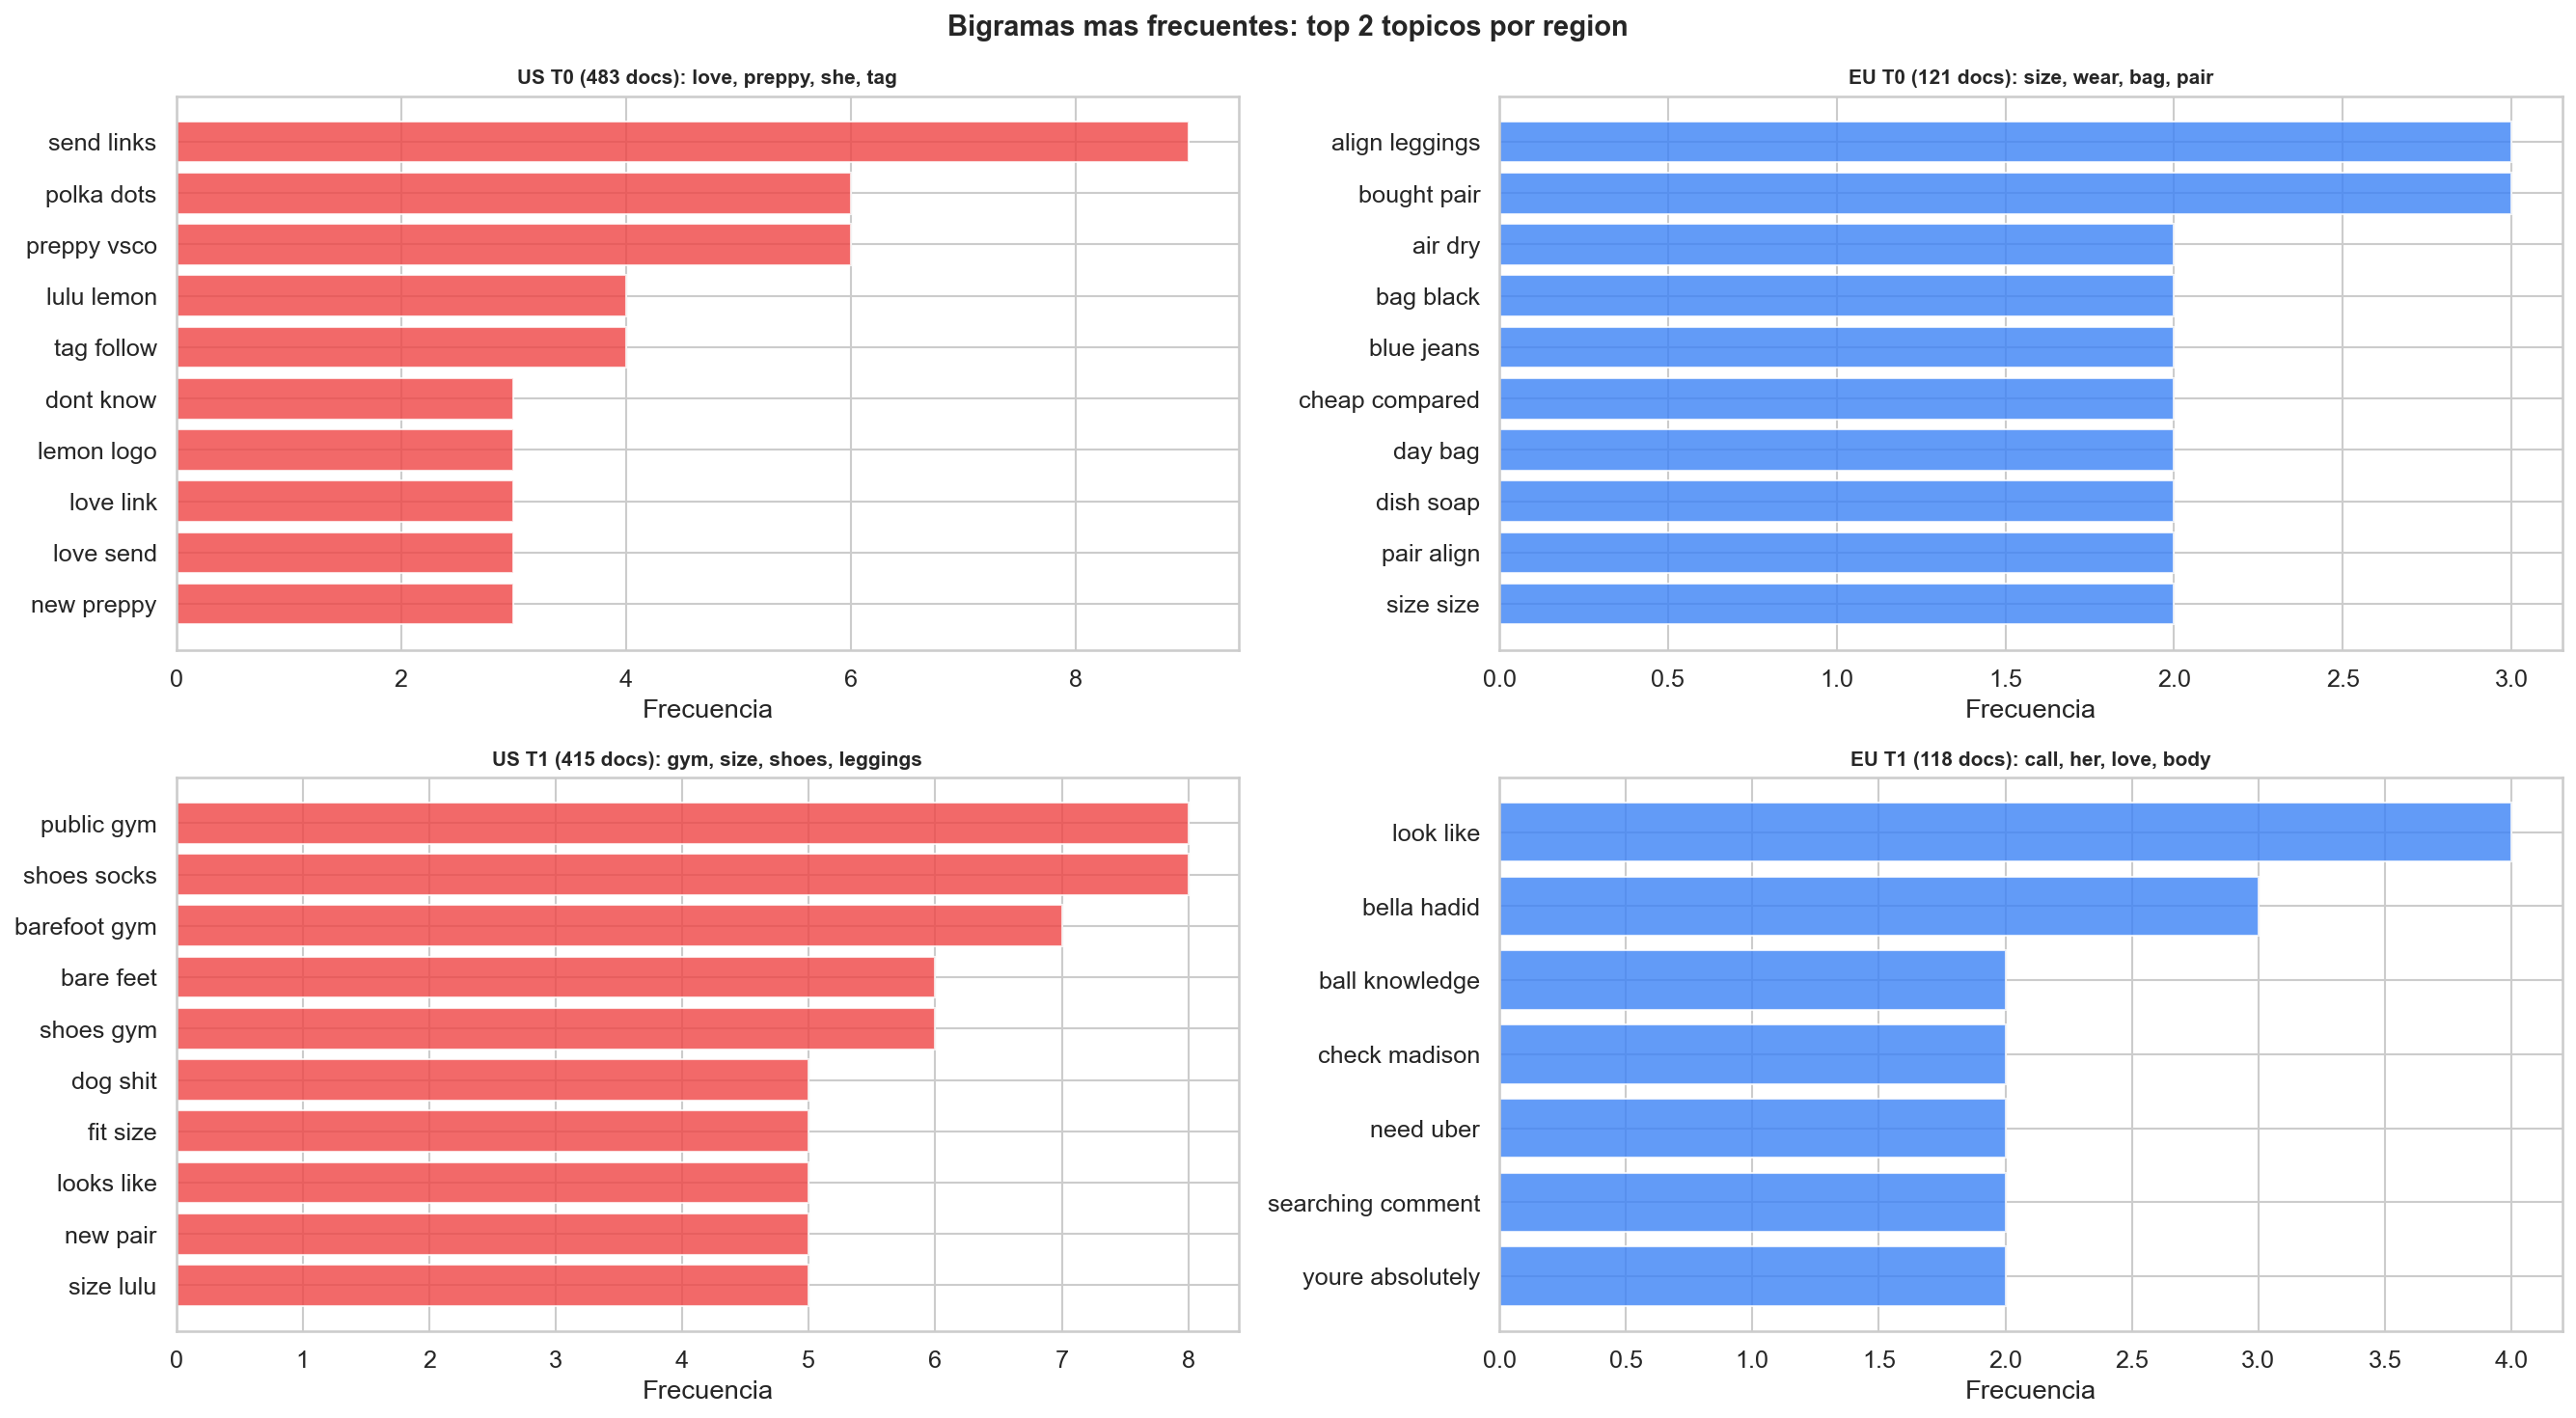

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_trigramas_top_topicos.png


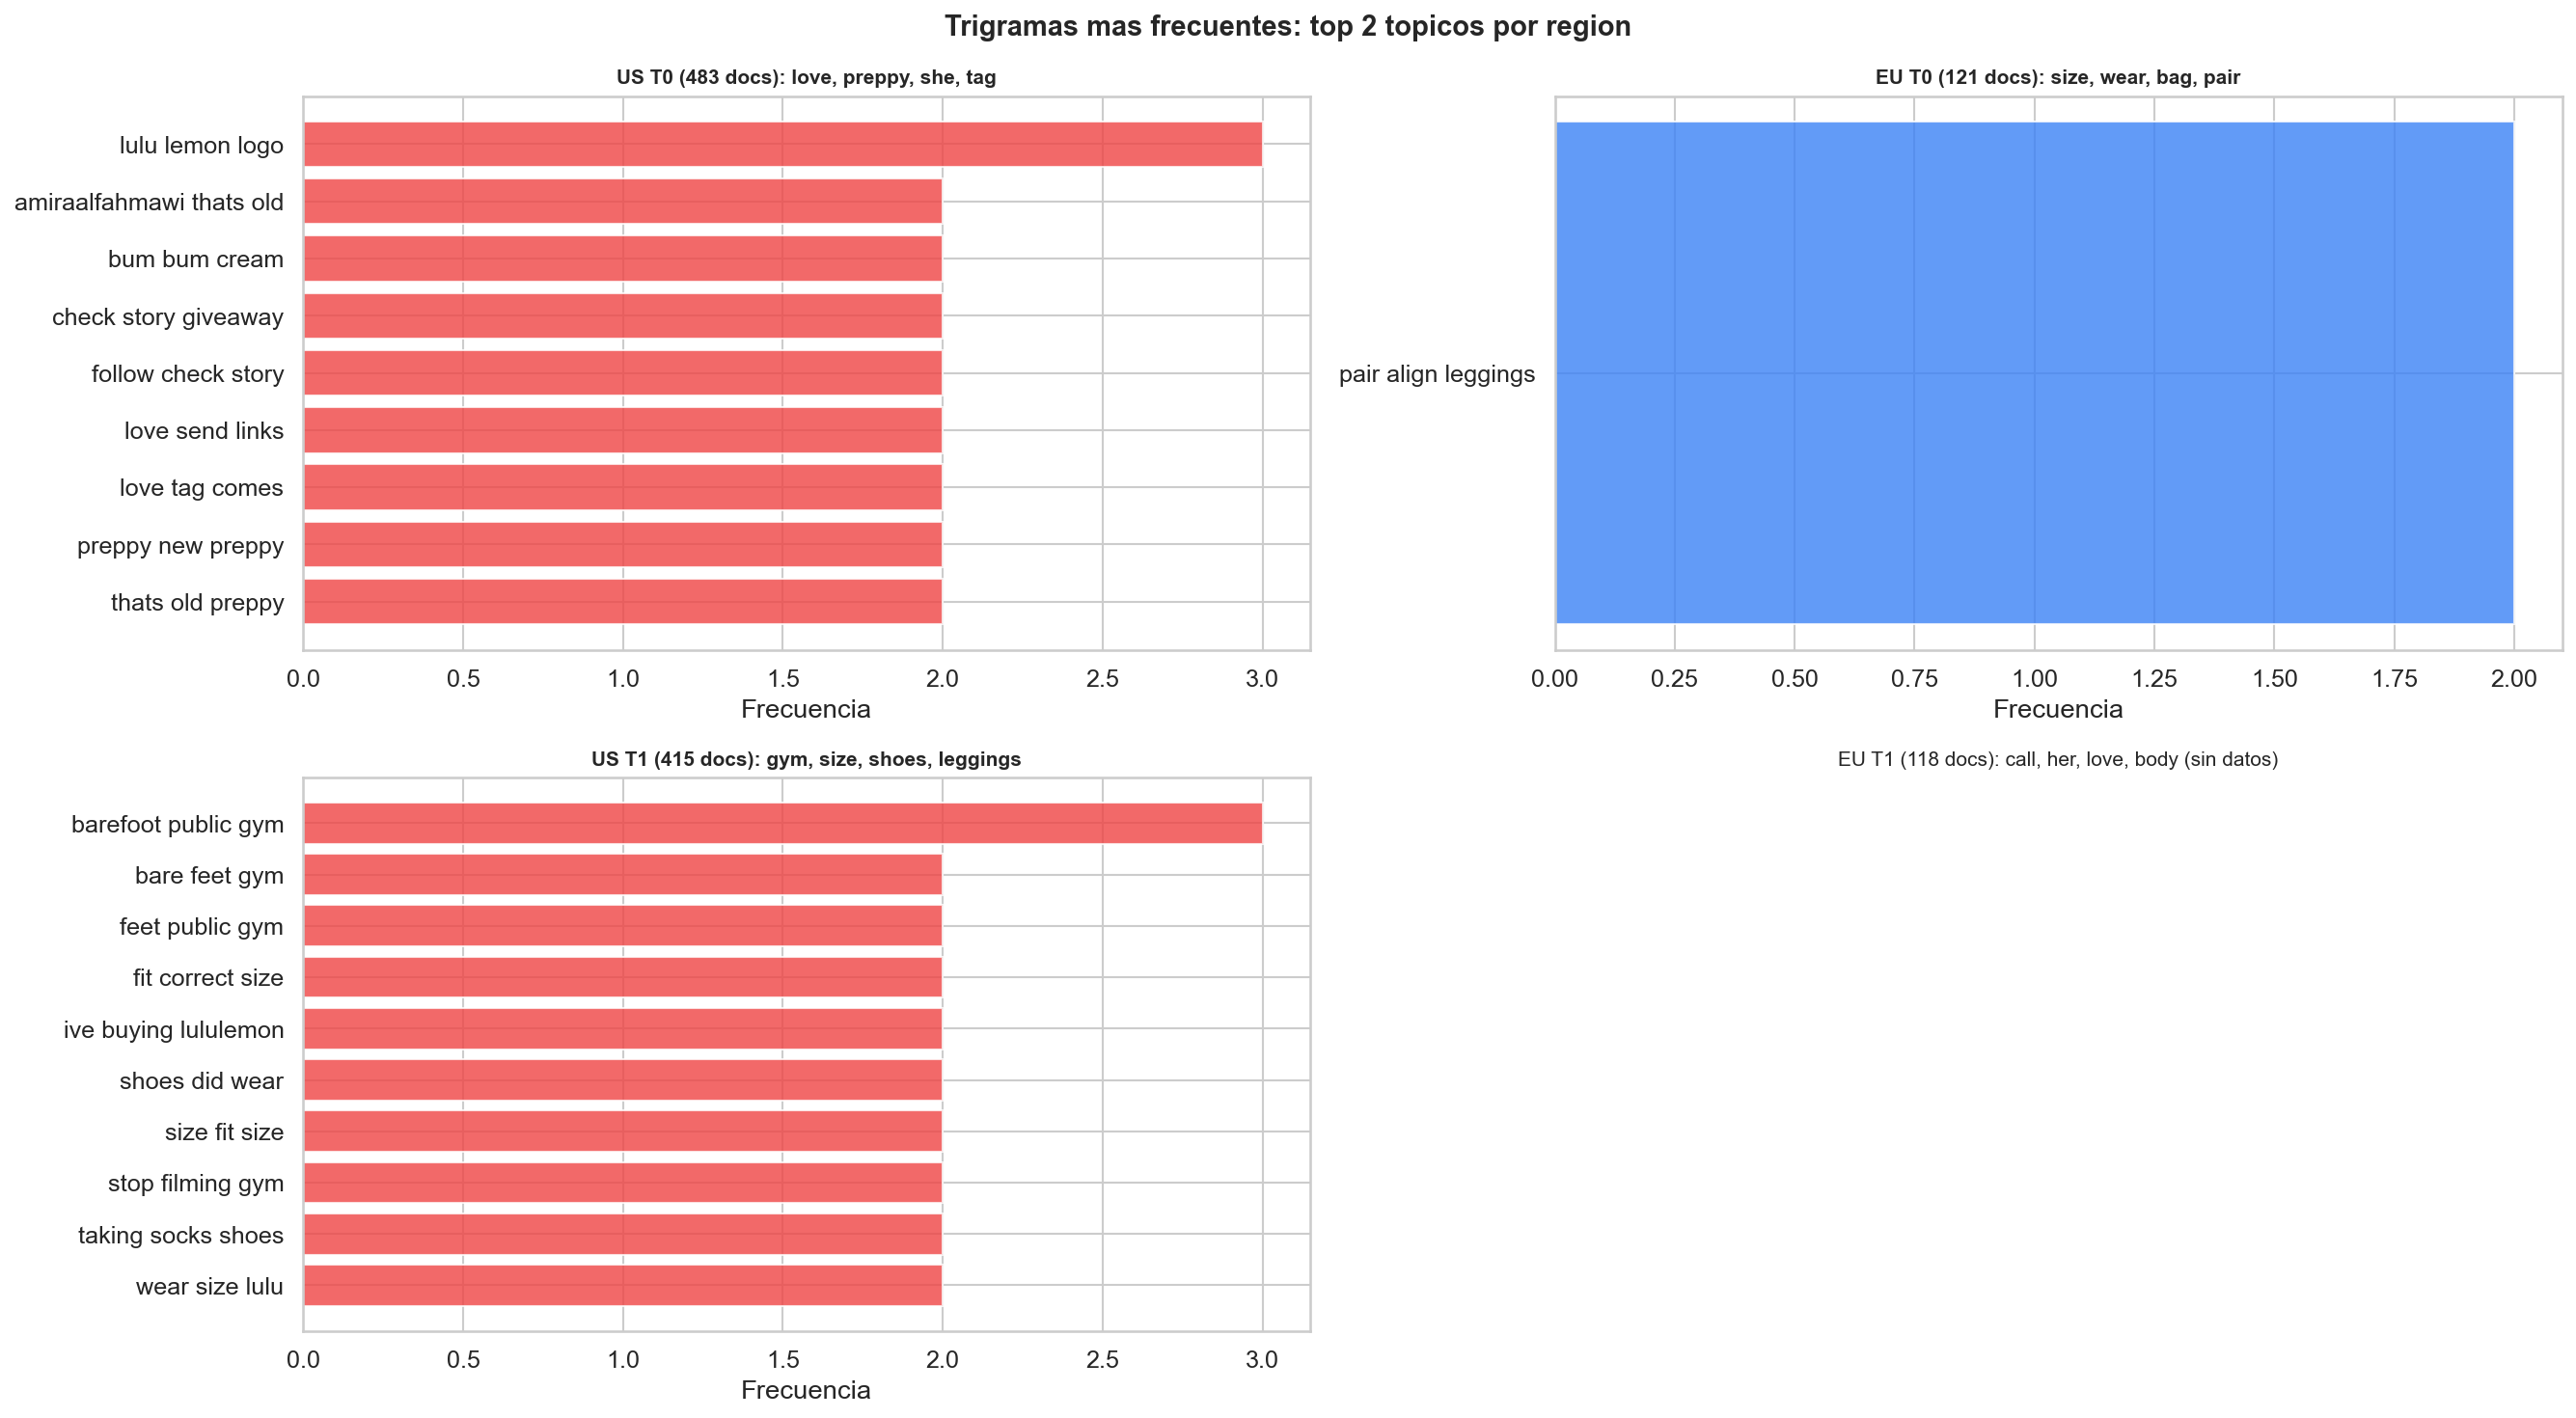

In [22]:
# Visualizar bigramas y trigramas de los top 2 topicos por region
from sklearn.feature_extraction.text import CountVectorizer as CV

def plot_ngrams(ax, texts, title, color, n=2):
    try:
        vec = CV(ngram_range=(n, n), stop_words="english", min_df=2, max_features=500,
                 token_pattern=r'\b[a-zA-Z]{3,}\b')
        X = vec.fit_transform(texts)
        freqs = sorted(zip(vec.get_feature_names_out(), X.sum(axis=0).A1), key=lambda x: x[1], reverse=True)[:10]
        grams = [g for g, _ in freqs]
        counts = [c for _, c in freqs]
        ax.barh(grams[::-1], counts[::-1], color=color, alpha=0.8)
        ax.set_title(title, fontweight="bold", fontsize=10)
        ax.set_xlabel("Frecuencia")
    except:
        ax.set_title(f"{title} (sin datos)", fontsize=10)
        ax.axis("off")

# --- BIGRAMAS ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for idx, tid in enumerate(top_us_topics[:2]):
    subset = us5[us5["topico_5"] == tid]
    words = ", ".join([w for w, _ in model_us_5.get_topic(tid)[:4]])
    plot_ngrams(axes[idx, 0], subset["text_en"].dropna().tolist(),
                f"US T{tid} ({len(subset)} docs): {words}", "#EF4444", n=2)

for idx, tid in enumerate(top_eu_topics[:2]):
    subset = eu5[eu5["topico_5"] == tid]
    words = ", ".join([w for w, _ in model_eu_5.get_topic(tid)[:4]])
    plot_ngrams(axes[idx, 1], subset["text_en"].dropna().tolist(),
                f"EU T{tid} ({len(subset)} docs): {words}", "#3B82F6", n=2)

plt.suptitle("Bigramas mas frecuentes: top 2 topicos por region", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "sent_bigramas_top_topicos")
plt.show()

# --- TRIGRAMAS ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for idx, tid in enumerate(top_us_topics[:2]):
    subset = us5[us5["topico_5"] == tid]
    words = ", ".join([w for w, _ in model_us_5.get_topic(tid)[:4]])
    plot_ngrams(axes[idx, 0], subset["text_en"].dropna().tolist(),
                f"US T{tid} ({len(subset)} docs): {words}", "#EF4444", n=3)

for idx, tid in enumerate(top_eu_topics[:2]):
    subset = eu5[eu5["topico_5"] == tid]
    words = ", ".join([w for w, _ in model_eu_5.get_topic(tid)[:4]])
    plot_ngrams(axes[idx, 1], subset["text_en"].dropna().tolist(),
                f"EU T{tid} ({len(subset)} docs): {words}", "#3B82F6", n=3)

plt.suptitle("Trigramas mas frecuentes: top 2 topicos por region", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "sent_trigramas_top_topicos")
plt.show()

**Interpretacion:** Los n-gramas revelan las expresiones concretas que usan los consumidores dentro de cada topico. Los comentarios con mas likes son los mas representativos de la opinion mayoritaria y sirven como citas directas para la presentacion.

## 7. Guardar datos con sentimiento y topicos

### 6.6 Export de tópicos para análisis externo

Exporta los datos de tópicos en formato texto para poder pasarlos a ChatGPT y generar tablas explicativas.

In [23]:
# =============================================
# EXPORT COMPLETO DE TOPICOS + COMENTARIOS
# =============================================
import os

output_path = "../../outputs/tablas/topicos_export_chatgpt.txt"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("=" * 100 + "\n")
    f.write("DATOS DE TOPICOS PARA ANALISIS - LULULEMON US vs EUROPA\n")
    f.write("=" * 100 + "\n\n")

    # --- SENTIMIENTO GENERAL POR REGION ---
    f.write("SENTIMIENTO GENERAL POR REGION (sin dividir por topico ni plataforma)\n")
    f.write("-" * 70 + "\n")
    for zone, df_zone in [("US", texts_us_clean), ("Europa", texts_eu_clean)]:
        n = len(df_zone)
        pct_pos = (df_zone["sentiment_label"] == "positivo").mean() * 100
        pct_neu = (df_zone["sentiment_label"] == "neutro").mean() * 100
        pct_neg = (df_zone["sentiment_label"] == "negativo").mean() * 100
        avg = df_zone["sentiment_stars"].mean()
        f.write(f"  {zone}: n={n}, positivo={pct_pos:.1f}%, neutro={pct_neu:.1f}%, negativo={pct_neg:.1f}%, media={avg:.2f} estrellas\n")
    f.write("\n")

    # --- SENTIMIENTO POR PLATAFORMA Y REGION ---
    f.write("SENTIMIENTO POR PLATAFORMA Y REGION\n")
    f.write("-" * 70 + "\n")
    for zone, df_zone in [("US", texts_us_clean), ("Europa", texts_eu_clean)]:
        for plat in ["instagram", "tiktok", "trustpilot"]:
            sub = df_zone[df_zone["platform"] == plat]
            if len(sub) == 0:
                continue
            pct_pos = (sub["sentiment_label"] == "positivo").mean() * 100
            pct_neg = (sub["sentiment_label"] == "negativo").mean() * 100
            avg = sub["sentiment_stars"].mean()
            f.write(f"  {zone} / {plat.capitalize()}: n={len(sub)}, positivo={pct_pos:.1f}%, negativo={pct_neg:.1f}%, media={avg:.2f}\n")
    f.write("\n\n")

    # --- TOPICOS POR REGION (5 forzados) ---
    for zone, model, df_zone in [("US", model_us_5, texts_us_clean), ("Europa", model_eu_5, texts_eu_clean)]:
        f.write("=" * 100 + "\n")
        f.write(f"TOPICOS {zone.upper()} (modelo de 5 topicos forzados)\n")
        f.write("=" * 100 + "\n\n")

        info = model.get_topic_info()
        valid = info[info["Topic"] != -1]
        df_t = df_zone[df_zone["topico_5"] != -1].copy()

        for _, row in valid.iterrows():
            tid = row["Topic"]
            subset = df_t[df_t["topico_5"] == tid]
            n_docs = len(subset)

            # Palabras clave
            words = [w for w, _ in model.get_topic(tid)[:10]]
            words_str = ", ".join(words)

            # Sentimiento
            pct_pos = (subset["sentiment_label"] == "positivo").mean() * 100
            pct_neg = (subset["sentiment_label"] == "negativo").mean() * 100
            avg_stars = subset["sentiment_stars"].mean()

            # Plataforma dominante
            plat_pct = subset["platform"].value_counts(normalize=True) * 100
            plat_str = " | ".join([f"{p.capitalize()}: {plat_pct.get(p, 0):.0f}%" for p in ["instagram", "tiktok", "trustpilot"]])

            f.write(f"TOPICO {tid} ({n_docs} comentarios)\n")
            f.write(f"  Palabras clave: {words_str}\n")
            f.write(f"  Sentimiento: positivo={pct_pos:.0f}%, negativo={pct_neg:.0f}%, media={avg_stars:.1f} estrellas\n")
            f.write(f"  Plataformas: {plat_str}\n")

            # Top 5 comentarios con mas likes
            if "likes" in subset.columns:
                top = subset.nlargest(5, "likes")
            else:
                top = subset.head(5)

            f.write(f"  Comentarios representativos (top por likes):\n")
            for j, (_, c) in enumerate(top.iterrows()):
                likes_val = c.get("likes", "?")
                text = str(c.get("text_en", c.get("text_clean", "")))[:300].replace("\n", " ")
                plat = c.get("platform", "?")
                sent = c.get("sentiment_label", "?")
                f.write(f"    {j+1}. [{plat}] ({likes_val} likes, {sent}) {text}\n")
            f.write("\n")

    # --- INSTRUCCION PARA CHATGPT ---
    f.write("\n" + "=" * 100 + "\n")
    f.write("INSTRUCCION PARA CHATGPT:\n")
    f.write("=" * 100 + "\n")
    f.write("Con los datos de arriba, genera una tabla para cada region (US y Europa) con las columnas:\n")
    f.write("- Topico (titulo descriptivo, ej: 'Problemas de envio', 'Estilo de vida')\n")
    f.write("- Palabras clave (las 5 mas representativas)\n")
    f.write("- Explicacion (1-2 frases describiendo de que habla el topico)\n")
    f.write("- Sentimiento dominante (positivo/negativo/mixto)\n")
    f.write("- Plataforma principal (donde aparece mas)\n")
    f.write("- N comentarios\n")
    f.write("\nAdemas, proporciona 5 estrategias de marketing accionables basadas en estos datos,\n")
    f.write("diferenciadas entre US y Europa, que una marca como Lululemon podria implementar.\n")

print(f"Exportado: {output_path}")
print(f"Tamaño: {os.path.getsize(output_path)} bytes")

# También leer y mostrar preview
with open(output_path, "r") as f:
    content = f.read()
print(f"\nPreview (primeras 2000 chars):\n")
print(content[:2000])

Exportado: ../../outputs/tablas/topicos_export_chatgpt.txt
Tamaño: 9931 bytes

Preview (primeras 2000 chars):

DATOS DE TOPICOS PARA ANALISIS - LULULEMON US vs EUROPA

SENTIMIENTO GENERAL POR REGION (sin dividir por topico ni plataforma)
----------------------------------------------------------------------
  US: n=1672, positivo=40.3%, neutro=14.8%, negativo=44.9%, media=2.91 estrellas
  Europa: n=407, positivo=41.5%, neutro=14.7%, negativo=43.7%, media=2.95 estrellas

SENTIMIENTO POR PLATAFORMA Y REGION
----------------------------------------------------------------------
  US / Instagram: n=917, positivo=41.2%, negativo=46.1%, media=2.89
  US / Tiktok: n=641, positivo=44.6%, negativo=35.6%, media=3.17
  US / Trustpilot: n=114, positivo=8.8%, negativo=87.7%, media=1.50
  Europa / Instagram: n=45, positivo=62.2%, negativo=33.3%, media=3.53
  Europa / Tiktok: n=303, positivo=43.2%, negativo=37.6%, media=3.10
  Europa / Trustpilot: n=59, positivo=16.9%, negativo=83.1%, media=1.76


TOP

In [24]:
ig_com.to_csv(f"{DATA}/ig_comentarios_sentiment.csv", index=False, encoding="utf-8-sig")
tk_com.to_csv(f"{DATA}/tiktok_comentarios_sentiment.csv", index=False, encoding="utf-8-sig")
tp.to_csv(f"{DATA}/trustpilot_all_sentiment.csv", index=False, encoding="utf-8-sig")
all_texts.to_csv(f"{DATA}/all_texts_sentiment_topics.csv", index=False, encoding="utf-8-sig")

tp_lulu = tp[tp["brand"] == "Lululemon"]
resumen_sent = pd.DataFrame({
    "Plataforma": ["Instagram", "TikTok", "Trustpilot Lulu", "Trustpilot ALO"],
    "N textos": [len(ig_com), len(tk_com), len(tp_lulu), len(tp[tp["brand"]=="ALO Yoga"])],
    "% Positivo": [
        f"{(ig_com['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(tk_com['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(tp_lulu['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(tp[tp['brand']=='ALO Yoga']['sentiment_label']=='positivo').mean()*100:.1f}%",
    ],
    "% Negativo": [
        f"{(ig_com['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{(tk_com['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{(tp_lulu['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{(tp[tp['brand']=='ALO Yoga']['sentiment_label']=='negativo').mean()*100:.1f}%",
    ],
    "Media estrellas": [
        f"{ig_com['sentiment_stars'].mean():.2f}",
        f"{tk_com['sentiment_stars'].mean():.2f}",
        f"{tp_lulu['sentiment_stars'].mean():.2f}",
        f"{tp[tp['brand']=='ALO Yoga']['sentiment_stars'].mean():.2f}",
    ],
})

resumen_sent.to_csv("../../outputs/tablas/sent_resumen.csv", index=False)
resumen_sent

,Plataforma,N textos,% Positivo,% Negativo,Media estrellas
0,Instagram,1433,51.4%,35.2%,3.28
1,TikTok,1056,46.5%,35.1%,3.20
2,Trustpilot Lulu,188,11.7%,85.6%,1.60
3,Trustpilot ALO,195,3.6%,96.4%,1.23
